# Representational Geometry in Neural Audio Models

This notebook contains exploratory experiments from my dissertation on how neural audio models represent features like pitch.

⚠️ Note: This notebook is provided for reference and readability. It is not intended to be executed end-to-end without additional setup.

# Part 1: Theoretical Expectations for Model Behavior

Guiding question: Are Narrowband Components Separate at Depth?

Since all architectures use strided convolution to downsample, we would not expect narrowband components from the original signal to persist into the deepest layers of the encoder. Rather, any that exist above the local Nyquist rate for a particular layer should fold into a low-frequency proxy. But what remains unknown is if that encoder preserves an injective mapping between the original components and their folded proxies. If so, the original components remain implicitly separate and controllable in the representation, by proxy.

This section demonstrates that narrowband components from the original signal fold into "alias orbits" at depth. This is an expansion of the classical DSP notion of aliasing, which says that two components are aliases if they fold to the same low-frequency component. I instead propose "alias orbits," which are sets of low-frequency components to which many components fold. This folding is deterministic and is given by the harmonicity of the components and their commensurability with the local sampling rate. Therefore, injectivity is uneven across models. Some induce more representatinoal collapse than others.

Note: Real musical data has an unknown number of components in unknown locations. To properly test models, therefore, I used carefully curated synthetic data (built below). This dataset is meant to mimic the structure of real musical data, while still allowing me to track individual components.

## Injectivity Changes with Harmonicity and Commensurability

**Theoretical Bound (Architecture Independent)**
This plot shows the injectivity bound. When y = n, the mapping is injective. When y < n, the mapping is non-injective (some original components have folded to the same low-frequency proxy).

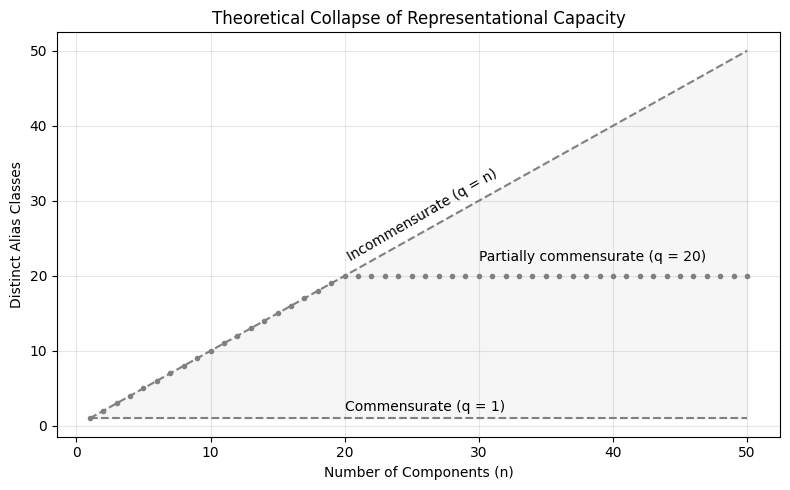

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Range of components
n = np.arange(1, 51)

plt.figure(figsize=(8, 5))

# Bounds
y_top = n
y_bottom = np.ones_like(n)

# Plot bounds
plt.plot(n, n, '--', label='Incommensurate (q = n)', color='gray')
plt.plot(n, np.minimum(n, 20), '.', label='Partial commensurability (q = 20)', color='gray')
plt.plot(n, np.minimum(n, 1), '--', label='Fully commensurate (q = 1)', color='gray')

# text at angle
plt.text(20, 22, 'Incommensurate (q = n)', fontsize=10, rotation=30)
plt.text(30, 22, 'Partially commensurate (q = 20)', fontsize=10)
plt.text(20, 2, 'Commensurate (q = 1)', fontsize=10)
plt.fill_between(n, y_bottom, y_top, color='lightgray', alpha=0.2)

# Labels and title
plt.xlabel('Number of Components (n)')
plt.ylabel('Distinct Alias Classes')
plt.title('Theoretical Collapse of Representational Capacity')

# Formatting
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

**Build the synthetic test dataset**

In [ ]:
import numpy as np

def alias_classes(freqs, fs=75, tol_hz=0.0):
    tol = tol_hz / fs

    alpha = (freqs / fs) % 1.0
    alpha = fold_to_nyquist(alpha)
    alpha_sorted = np.sort(alpha)

    classes = [alpha_sorted[0]]

    for a in alpha_sorted[1:]:
        if abs(a - classes[-1]) > tol:
            classes.append(a)

    return len(classes)

def fold_to_nyquist(alpha):
    return np.minimum(alpha, 1 - alpha)

def alias_stats(freqs, fs, tol_hz=0.0):
    tol = tol_hz / fs

    alpha = (freqs / fs) % 1.0
    alpha = fold_to_nyquist(alpha)
    alpha_sorted = np.sort(alpha)

    # count classes
    classes = [alpha_sorted[0]]
    for a in alpha_sorted[1:]:
        if abs(a - classes[-1]) > tol:
            classes.append(a)
    y = len(classes)

    # min pairwise distance in normalized units
    if len(alpha_sorted) > 1:
        diffs = np.diff(alpha_sorted)
        min_dist = np.min(diffs)
    else:
        min_dist = 1.0

    return y, min_dist, np.array(classes)

# Harmonic (e.g., violin, brass)
def harmonic_stack(f0, n, jitter=0.0):
    k = np.arange(1, n+1)
    eps = np.random.normal(0, jitter, size=n)
    return f0 * k * (1 + eps)

# Inharmonic (e.g., piano, guitar)
def inharmonic_stack(f0, n, B):
    k = np.arange(1, n+1)
    return f0 * k * np.sqrt(1 + B * k**2)

def commensurate_f0(fs, q_max=10):
    q = np.random.randint(1, q_max + 1)
    p = np.random.randint(1, q)
    return (p / q) * fs, q

def near_commensurate_f0(fs, fmin=50, fmax=1000, q_choices=[2,3,5,10,20], delta_scale=0.0):
    while True:
        q = np.random.choice(q_choices)
        p = np.random.randint(1, q)
        delta = np.random.uniform(-delta_scale, delta_scale)
        f0 = fs * (p / q + delta)
        if fmin <= f0 <= fmax:
            return f0, q

# Ensure harmonic and commensurate
def generate_class_A(fs, q_values=[1,2,3,5,10,15,20], n_values=[3,5,8,12,15,18,20]):
    data = []
    for q in q_values:
        for p in range(1, q):
            f0 = (p / q) * fs
            for n in n_values:
                freqs = harmonic_stack(f0, n, jitter=0.0)
                y, min_dist, aliases = alias_stats(freqs, fs, tol_hz=0.0)
                data.append((n, y, min_dist, 'harmonic_comm', freqs, aliases))
    return data

# Mixed harmonicity and commensurability
def generate_dataset(num_samples=300, fs=100, tolerance=0.0):
    data = generate_class_A(fs)
    choices = ['harmonic_rand', 'near_harmonic', 'inharmonic', 'mixture']

    for _ in range(num_samples):
        choice = np.random.choice(choices)
        if choice == 'harmonic_rand':
            n = np.random.randint(3, 10)
            f0 = np.random.uniform(50, 1000)
            freqs = harmonic_stack(f0, n, jitter=0.0)
        elif choice == 'near_harmonic':
            n = np.random.randint(3, 12)
            f0, _ = near_commensurate_f0(fs, delta_scale=1e-3)
            freqs = harmonic_stack(f0, n, jitter=0.0)
        elif choice == 'inharmonic':
            n = np.random.randint(3, 10)
            f0 = np.random.uniform(50, 1000)
            B = np.random.uniform(1e-4, 5e-3)
            freqs = inharmonic_stack(f0, n, B)
        elif choice == 'mixture':
            n_total = np.random.randint(6, 20)
            num_stacks = np.random.randint(2, 4)
            parts = np.random.multinomial(n_total, np.ones(num_stacks)/num_stacks)
            freqs = []
            for n_i in parts:
                sub = np.random.choice(['harmonic_rand', 'near_harmonic', 'inharmonic'])
                if sub == 'harmonic_rand':
                    f0 = np.random.uniform(50, 1000)
                    freqs.extend(harmonic_stack(f0, n_i, jitter=0.0))
                elif sub == 'near_harmonic':
                    f0, _ = near_commensurate_f0(fs, delta_scale=1e-3)
                    freqs.extend(harmonic_stack(f0, n_i, jitter=0.0))
                else:
                    f0 = np.random.uniform(50, 1000)
                    B = np.random.uniform(1e-4, 5e-3)
                    freqs.extend(inharmonic_stack(f0, n_i, B))
            freqs = np.array(freqs)

        n_total = len(freqs)
        y, min_dist, aliases = alias_stats(freqs, fs, tol_hz=tolerance)
        data.append((n_total, y, min_dist, choice, freqs, aliases))

    return data

fs = 75 # most models have latent sr somewhere in this range
data = generate_dataset(num_samples=300, fs=fs, tolerance=0.0)

**Dataset Folding Stats**

This code asks what component spacing in the dataset looks like before and after folding.

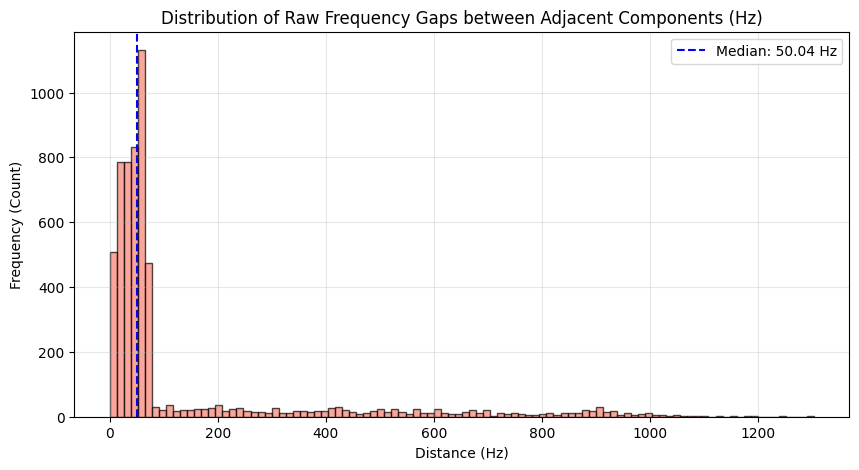

Summary of Raw Spectral Gaps (Hz):
Max Gap:    1303.21 Hz
Min Gap:    0.0446 Hz
Mean Gap:   132.94 Hz
Total Count of Gaps: 5712


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def check_raw_gaps(data):
    raw_gaps = []
    for item in data:
        # item is (n, y, min_dist, label, freqs)
        freqs = np.sort(item[4])
        if len(freqs) > 1:
            diffs = np.diff(freqs)
            raw_gaps.extend(diffs.tolist())
    return np.array(raw_gaps)

gaps_hz = check_raw_gaps(data)

plt.figure(figsize=(10, 5))
plt.hist(gaps_hz, bins=100, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(np.median(gaps_hz), color='blue', linestyle='--', label=f'Median: {np.median(gaps_hz):.2f} Hz')
plt.title('Distribution of Raw Frequency Gaps between Adjacent Components (Hz)')
plt.xlabel('Distance (Hz)')
plt.ylabel('Frequency (Count)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Summary of Raw Spectral Gaps (Hz):")
print(f"Max Gap:    {np.max(gaps_hz):.2f} Hz")
print(f"Min Gap:    {np.min(gaps_hz):.4f} Hz")
print(f"Mean Gap:   {np.mean(gaps_hz):.2f} Hz")
print(f"Total Count of Gaps: {len(gaps_hz)}")

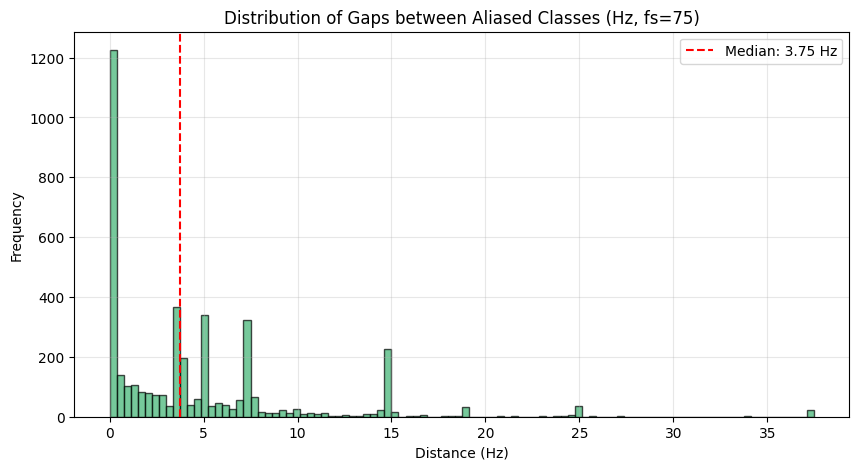

Summary of Aliased Gaps (Hz):
Max Gap:    37.50 Hz
Min Gap:    1.0408e-15 Hz
Mean Gap:   4.54 Hz
Total Gaps: 4083


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def check_aliased_gaps_hz(data, fs):
    all_gaps_hz = []
    for item in data:
        # item is (n, y, min_dist, label, freqs, aliases)
        aliases = item[5]
        if len(aliases) > 1:
            # Convert normalized aliases back to Hz before diffing
            # or diff then multiply by fs
            diffs = np.diff(aliases) * fs
            all_gaps_hz.extend(diffs.tolist())
    return np.array(all_gaps_hz)

aliased_gaps_hz = check_aliased_gaps_hz(data, fs)

plt.figure(figsize=(10, 5))
plt.hist(aliased_gaps_hz, bins=100, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.axvline(np.median(aliased_gaps_hz), color='red', linestyle='--', label=f'Median: {np.median(aliased_gaps_hz):.2f} Hz')
plt.title(f'Distribution of Gaps between Aliased Classes (Hz, fs={fs})')
plt.xlabel('Distance (Hz)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Summary of Aliased Gaps (Hz):")
print(f"Max Gap:    {np.max(aliased_gaps_hz):.2f} Hz")
print(f"Min Gap:    {np.min(aliased_gaps_hz):.4e} Hz")
print(f"Mean Gap:   {np.mean(aliased_gaps_hz):.2f} Hz")
print(f"Total Gaps: {len(aliased_gaps_hz)}")

**Plot synthetic test data on the template above**

This plot shows the degree to which individual components in the dataset collapse to alias orbits.

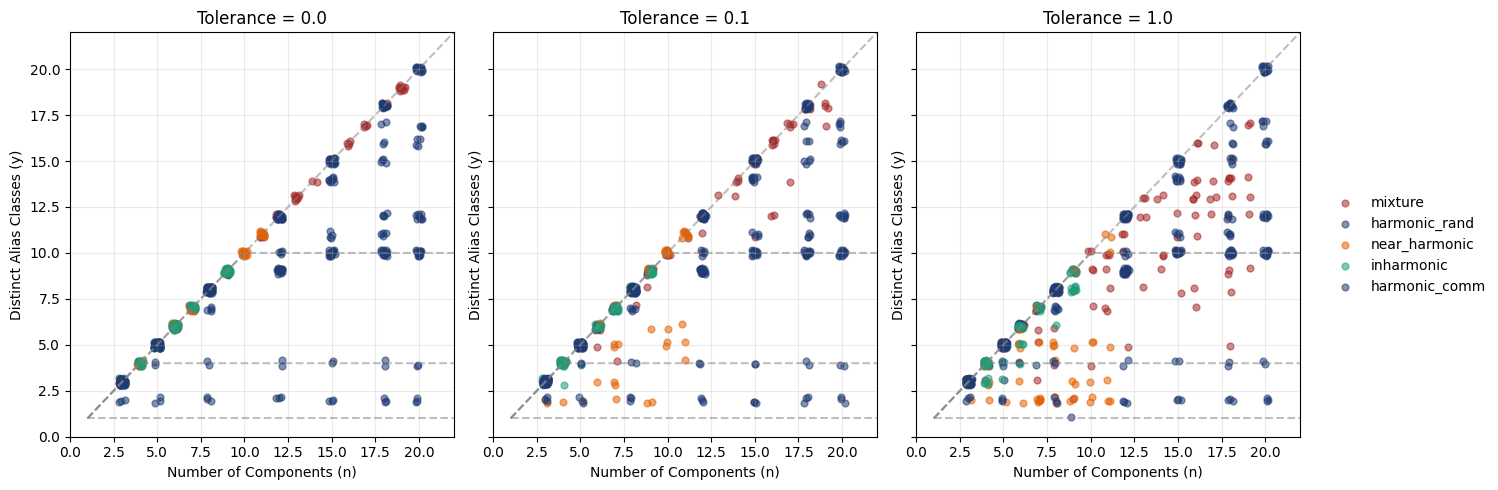

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# jitter slightly for visibility
def jitter(val, scale=0.18):
    return val + np.random.uniform(-scale, scale)

def plot_bounds(ax, n_max=25):
    n = np.linspace(1, n_max, 200)
    ax.plot(n, n, '--', color='gray', alpha=0.5)
    ax.plot(n, np.ones_like(n), '--', color='gray', alpha=0.5)
    ax.plot(n, np.minimum(n, 10), '--', color='gray', alpha=0.5)
    ax.plot(n, np.minimum(n, 4), '--', color='gray', alpha=0.5)

def plot_dataset(ax, data):

    colors = {
        'harmonic_comm': '#1f3b73',
        'harmonic_rand': '#1f3b73',
        'near_harmonic': '#e66100',
        'inharmonic':    '#1b9e77',
        'mixture':       'brown'}

    plot_bounds(ax, n_max=25)

    order = ['mixture', 'harmonic_rand', 'near_harmonic', 'inharmonic', 'harmonic_comm']

    for cls in order:
        subset = [(n, y) for (n, y, _, label, _) in data if label == cls]

        if not subset:
            continue

        n_vals = [jitter(n) for (n, y) in subset]
        y_vals = [jitter(y) for (n, y) in subset]

        ax.scatter(
            n_vals,
            y_vals,
            color=colors[cls],
            alpha=0.55,
            s=24,
            label=cls
        )

    ax.set_xlabel('Number of Components (n)')
    ax.set_ylabel('Distinct Alias Classes (y)')

    ax.set_xlim(0, 22)
    ax.set_ylim(0, 22)

    ax.grid(True, alpha=0.25)

# figure
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

tol = [0.0, 0.1, 1.0]

for i, ax in enumerate(axs):
    data = generate_dataset(num_samples=300, tolerance=tol[i])
    plot_dataset(ax, data)
    ax.set_title(f"Tolerance = {tol[i]}")

# legend outside
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center right',
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for legend
plt.show()

In [ ]:
# dataset stats
quantiles = [0.25, 0.5, 0.75, 0.9]

print("Quantiles (fraction of Nyquist):")
for q in quantiles:
    val = np.quantile(aliased_gaps, q)
    print(f"{int(q*100)}%: {val:.5f}")

# Also count the exact collisions (effectively 0 Hz)
collisions = (aliased_gaps < 1e-6).mean() * 100
print(f"Near-zero collisions: {collisions:.2f}%")

Quantiles (fraction of Nyquist):
25%: 0.00253
50%: 0.05000
75%: 0.08963
90%: 0.18190
Near-zero collisions: 18.66%


**Selectivity plot**

This plot shows average empirical selectivity for filters in the last layer of four different models against this data––given the folded spacing, how much could the average filter resolve? Note that these bandwidths are computed in subsequent sections but were added here for reference.

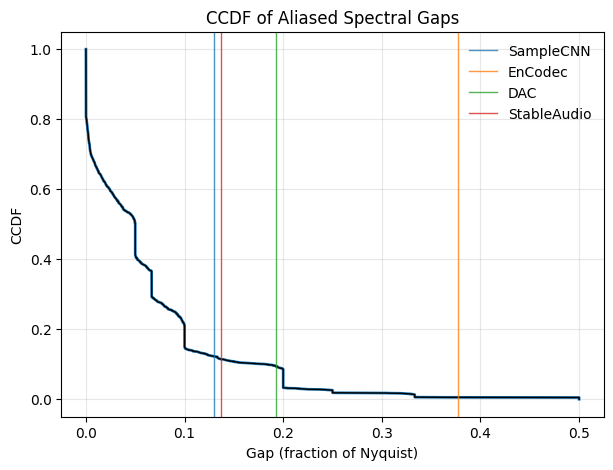

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(gaps_sorted, ccdf, linewidth=2)

ax.set_xscale('linear')
ax.set_xlabel('Gap (fraction of Nyquist)')
ax.set_ylabel('CCDF')
ax.set_title('CCDF of Aliased Spectral Gaps')
ax.grid(True, alpha=0.3)

colors = {
    "SampleCNN": "tab:blue",
    "EnCodec": "tab:orange",
    "DAC": "tab:green",
    "StableAudio": "tab:red"
}

model_names = ["SampleCNN", "EnCodec", "DAC", "StableAudio"]
model_bws = [1.31, 14.16, 8.30, 1.47] # derived from code below
model_fs = [2.24, 75, 86.13, 21.53] # local sr from model architecture
model_bws_norm = np.array(model_bws) / np.array(model_fs)

# Plot CCDF
ax.plot(gaps_sorted, ccdf, color='black', linewidth=1)

# Plot model bandwidths
for name, bw in zip(model_names, model_bws_norm):
    ax.axvline(bw, color=colors[name], linewidth=1, label=name, alpha=0.8)

ax.legend(frameon=False)

## Ablations
Given that Western music has fixed fundamental frequencies (although these vary slightly in practice), how much collapse might we expect across pitches built on all musical fundementals for different latent sampling rates? The plots show that collapse into alias orbits happens differently across the most common sampling rates used in audio modeling (44.1k induces virtually no collapse, whereas 8k and its multiples induce significant and consistent collapse).

In [ ]:
import numpy as np
from itertools import product
from tqdm.notebook import tqdm

def midi_to_hz(midi):
    return 440.0 * (2 ** ((midi - 69) / 12.0))

def get_fundamentals():
    # A0 (21) to C8 (108)
    midi_notes = np.arange(21, 109)
    return midi_to_hz(midi_notes)

def harmonic_stack(f0, n):
    return f0 * np.arange(1, n + 1)

def alias_freqs(freqs, fs):
    alpha = (freqs / fs) % 1.0
    alpha = np.minimum(alpha, 1 - alpha)
    return alpha * fs  # back to Hz


def count_clusters(freqs, tol_hz):
    freqs = np.sort(freqs)
    clusters = [freqs[0]]

    for f in freqs[1:]:
        if abs(f - clusters[-1]) > tol_hz:
            clusters.append(f)

    return len(clusters)


def preservation(f0, fs, n, tol_frac):
    freqs = f0 * np.arange(1, n + 1)
    aliased = alias_freqs(freqs, fs)

    tol_hz = tol_frac * fs

    y = count_clusters(aliased, tol_hz)
    return y / n

def score_sr(fs, fundamentals, n, tol_frac):
    vals = np.array([
        preservation(f0, fs, n, tol_frac)
        for f0 in fundamentals
    ])

    return {
        "mean_preservation": vals.mean(),
        "perfect_rate": (vals == 1.0).mean(),
        "all": vals}

def evaluate_path(path, fundamentals, tol_frac, n=5, fs_init=44100):
    fs_final = fs_init / np.prod(path)

    vals = np.array([
        preservation(f0, fs_final, n, tol_frac)
        for f0 in fundamentals
    ])

    return {
        "mean_preservation": vals.mean(),
        "perfect_rate": (vals == 1.0).mean(),
        "all": vals,
        "final_sr": fs_fina}

def enumerate_paths(strides=[2,3,4,5,8], max_depth=9, min_sr=10, max_sr=100, fs_init=44100):
    paths = []

    for depth in range(1, max_depth+1):
        for p in product(strides, repeat=depth):
            fs = fs_init / np.prod(p)
            if min_sr <= fs <= max_sr:
                paths.append(p)

    return paths

def evaluate_all_paths(paths, fundamentals, tol_frac, n=5, fs_init=44100):
    results = []

    for path in tqdm(paths):
        eval_result = evaluate_path(path, fundamentals, tol_frac, n=n, fs_init=fs_init)

        results.append({
            "path": path,
            "final_sr": eval_result["final_sr"],
            "mean_preservation": eval_result["mean_preservation"],
            "perfect_rate": eval_result["perfect_rate"]
        })

    return results

fundamentals = get_fundamentals()

tol_frac = 2e-5  # fraction of sr
fs_inits = [8000, 16000, 22050, 24000, 32000, 44100, 48000]

results_dict = {}
for fs_init in tqdm(fs_inits):
    paths = enumerate_paths(max_depth=9, min_sr=2, fs_init=fs_init)
    results = evaluate_all_paths(paths, fundamentals, tol_frac, n=15, fs_init=fs_init)
    results_dict[fs_init] = results

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/33799 [00:00<?, ?it/s]

  0%|          | 0/79873 [00:00<?, ?it/s]

  0%|          | 0/112962 [00:00<?, ?it/s]

  0%|          | 0/128488 [00:00<?, ?it/s]

  0%|          | 0/177064 [00:00<?, ?it/s]

  0%|          | 0/242927 [00:00<?, ?it/s]

  0%|          | 0/272242 [00:00<?, ?it/s]

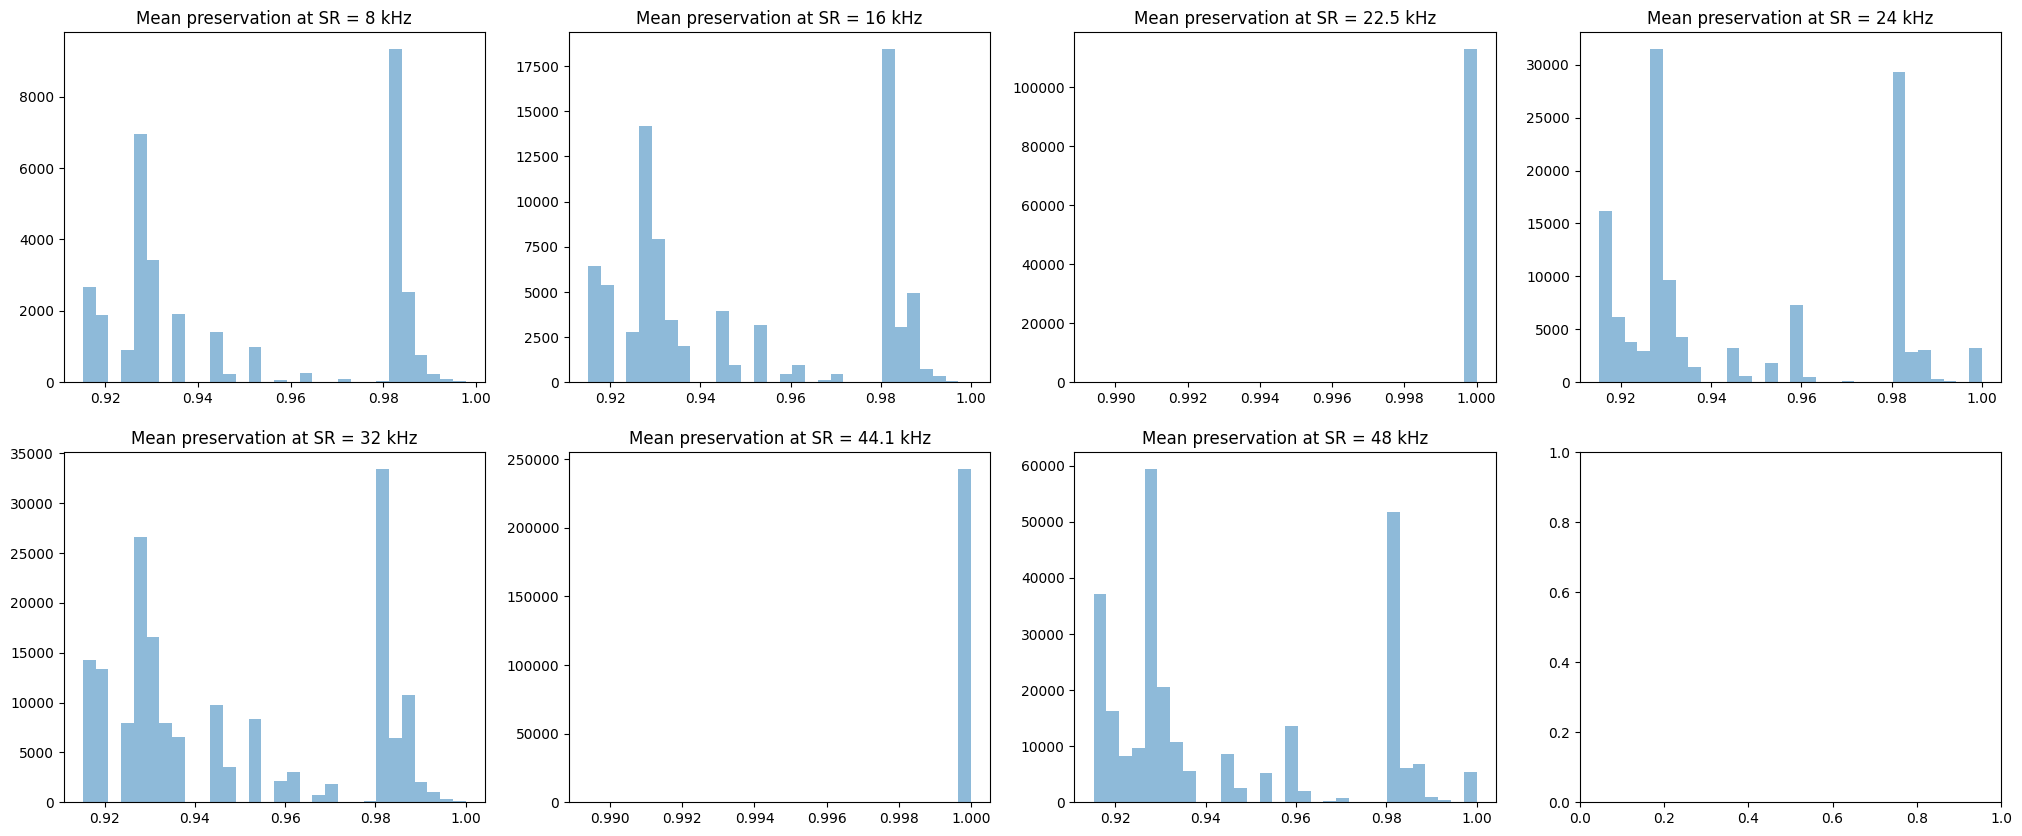

In [ ]:
# subplots
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 4, figsize=(25, 10))

vals1 = [r["mean_preservation"] for r in results_dict[8000]]
axs[0, 0].hist(vals1, bins=30, alpha=0.5)
axs[0, 0].set_title('Mean preservation at SR = 8 kHz')

vals2 = [r["mean_preservation"] for r in results_dict[16000]]
axs[0, 1].hist(vals2, bins=30, alpha=0.5)
axs[0, 1].set_title('Mean preservation at SR = 16 kHz')

vals3 = [r["mean_preservation"] for r in results_dict[22050]]
axs[0, 2].hist(vals3, bins=30, alpha=0.5)
axs[0, 2].set_title('Mean preservation at SR = 22.5 kHz')

vals4 = [r["mean_preservation"] for r in results_dict[24000]]
axs[0, 3].hist(vals4, bins=30, alpha=0.5)
axs[0, 3].set_title('Mean preservation at SR = 24 kHz')

vals5 = [r["mean_preservation"] for r in results_dict[32000]]
axs[1, 0].hist(vals5, bins=30, alpha=0.5)
axs[1, 0].set_title('Mean preservation at SR = 32 kHz')

vals6 = [r["mean_preservation"] for r in results_dict[44100]]
axs[1, 1].hist(vals6, bins=30, alpha=0.5)
axs[1, 1].set_title('Mean preservation at SR = 44.1 kHz')

vals7 = [r["mean_preservation"] for r in results_dict[48000]]
axs[1, 2].hist(vals7, bins=30, alpha=0.5)
axs[1, 2].set_title('Mean preservation at SR = 48 kHz')

plt.show()

In [ ]:
# sort by mean preservation (descending)
top_results = sorted(results_dict[24000], key=lambda x: x["mean_preservation"], reverse=True)

# print top 10
for i, r in enumerate(top_results[:10]):
    print(f"Rank {i+1}")
    print(f"  Path: {r['path']}")
    print(f"  Final SR: {r['final_sr']:.2f}")
    print(f"  Mean preservation: {r['mean_preservation']:.4f}")
    print(f"  Perfect rate: {r['perfect_rate']:.4f}")
    print()

# print bottom 10
bottom_results = sorted(results, key=lambda x: x["mean_preservation"])

for i, r in enumerate(bottom_results[:10]):
    print(f"Rank {i+1} (worst)")
    print(f"  Path: {r['path']}")
    print(f"  Final SR: {r['final_sr']:.2f}")
    print(f"  Mean preservation: {r['mean_preservation']:.4f}")
    print(f"  Perfect rate: {r['perfect_rate']:.4f}")
    print()

# compare to SampleCNN as a baseline
baseline = (3,3,3,3,3,3,3,3)

baseline_eval = evaluate_path(baseline, fundamentals, tol_frac, n=5)

print("Baseline (SampleCNN-like):")
print(f"  Mean preservation: {baseline_eval['mean_preservation']:.4f}")
print(f"  Perfect rate: {baseline_eval['perfect_rate']:.4f}")

Rank 1
  Path: (4, 8, 8)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 2
  Path: (8, 4, 8)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 3
  Path: (8, 8, 4)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 4
  Path: (8, 8, 8)
  Final SR: 46.88
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 5
  Path: (2, 2, 8, 8)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 6
  Path: (2, 4, 4, 8)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 7
  Path: (2, 4, 8, 4)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 8
  Path: (2, 4, 8, 8)
  Final SR: 46.88
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 9
  Path: (2, 8, 2, 8)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 10
  Path: (2, 8, 4, 4)
  Final SR: 93.75
  Mean preservation: 1.0000
  Perfect rate: 1.0000

Rank 1 (worst)
  Path: (3, 4, 5

# Part 2: Empirical Validation

For each model, we do a representability analysis (are components preserved?) and a separability analysis (are preserved components separable into independent representations?). The former is empirical validation that SOTA models behave like theory from part 1 predicts. The latter shows how separable components are, based on the bandwidths of learned filters in the encoder's last layer.

Motivation for separability: Even if the encoder preserves an injective mapping between the input components and their downsampled proxies, can filters at or preceding the last layer of the encoder separate these, such that the last layer could compose them into something like pitch? The section below asks this question for 4 state-of-the-art models: SampleCNN (my slightly altered re-engineered version), EnCodec, DAC, and StableAudio.  

## SampleCNN

### Load Model

In [ ]:
#Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Deep learning
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder

#Signal processing
import librosa
import librosa.display

# Function to play and write wav files
!pip install soundfile
import soundfile as sf
from IPython.display import Audio

#Logistics
import os
from tqdm import tqdm

In [ ]:
class SampleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SampleCNN, self).__init__()

        # Define the convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=3, stride=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, stride=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3),
            nn.Conv1d(128, 256, kernel_size=3, stride=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3),
            nn.Conv1d(256, 256, kernel_size=3, stride=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3),
            nn.Conv1d(256, 256, kernel_size=3, stride=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3),
            nn.Conv1d(256, 512, kernel_size=3, stride=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3),
            nn.Conv1d(512, 512, kernel_size=3, stride=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(3, stride=3), #could take this down to 1 and see how it changes the calculation
            nn.Conv1d(512, 512, kernel_size=3, stride=3),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        # Fully connected layers
        self.fc1 = nn.Linear(3584, 1024)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model1 = SampleCNN(num_classes=8)

In [ ]:
'''
Load a previously trained model here
'''

### Representability Analysis

Given encoder activations at each conv layer and the ground-truth input component frequencies for that signal, compute the expected alias modes (based on theoretical downsampling), how much activation-spectrum energy sits near those modes, and how many of those expected modes are present.

In [ ]:
def get_samplecnn_sr_map(model, base_sr=44100):
    sr = base_sr
    sr_map = []

    for i, module in enumerate(model.conv_layers):
        stride = get_stride_generic(module)
        if stride is not None and stride > 1:
            sr = sr / stride

        sr_map.append((i, type(module).__name__, sr))

    return sr_map

def forward_with_activations_samplecnn(model, x, base_sr=44100):
    activations = []

    current = x  # [B, 1, T]
    current_sr = base_sr

    for i, module in enumerate(model.conv_layers):
        current = module(current)

        # update SR for both conv + pool
        stride = get_stride_generic(module)
        if stride is not None and stride > 1:
            current_sr = current_sr / stride

        if isinstance(module, torch.nn.Conv1d):
            activations.append({
                "module": module,
                "layer_idx": i,
                "activation": current.detach().cpu(),
                "sampling_rate": current_sr
            })

    return activations

def get_stride_generic(module):
    if isinstance(module, torch.nn.Conv1d):
        return module.stride[0]

    if isinstance(module, torch.nn.MaxPool1d):
        stride = module.stride
        return stride[0] if isinstance(stride, tuple) else stride

    if hasattr(module, "conv"):
        return get_stride_generic(module.conv)

    if hasattr(module, "convtr"):
        return get_stride_generic(module.convtr)

    return None

def generate_multi_sine(freqs, sr=44100, duration=3.0):
    t = np.arange(0, duration, 1/sr)

    x = np.zeros_like(t)

    for f in freqs:
        x += np.sin(2 * np.pi * f * t)

    x = x / len(freqs)
    x = torch.tensor(x, dtype=torch.float32)
    x = x.unsqueeze(0).unsqueeze(0)

    return x

# per channel spectra for each output
def compute_fft_per_channel(x, sr):
    """
    x: (C, T)
    """
    x = x - x.mean(dim=-1, keepdim=True)
    fft = torch.fft.rfft(x, dim=-1)
    mag = torch.abs(fft)
    freqs = torch.fft.rfftfreq(x.shape[-1], d=1/sr)
    return freqs, mag

def unique_with_tol(freqs, tol=0.1):
    unique = []
    for f in freqs:
        if not any(abs(f - u) < tol for u in unique):
            unique.append(f)
    return unique

def alias_frequency(f, fs, eps=1e-8):
    f_mod = f % fs

    # snap tiny values to zero to handle numerical precision
    if abs(f_mod) < eps:
        f_mod = 0.0

    if f_mod > fs / 2:
        f_mod = fs - f_mod

    if abs(f_mod) < eps:
        f_mod = 0.0

    return f_mod

def expected_modes_theoretical(freqs, sr, tol, eps=1e-8):
    aliases = [alias_frequency(f, sr) for f in freqs]

    # remove near-zero (DC)
    aliases = [f for f in aliases if f > eps]

    # if everything collapsed to DC, return empty safely
    if len(aliases) == 0:
        return 0, []

    unique = unique_with_tol(aliases, tol=tol)

    return len(unique), unique

# track spectral peaks
def get_peak_freqs(freqs, energy, top_k=20):
    energy_np = energy.cpu().numpy()
    freqs_np = freqs.cpu().numpy()

    # remove DC
    freqs_np = freqs_np[1:]
    energy_np = energy_np[1:]

    peaks = []
    for i in range(1, len(energy_np) - 1):
        if energy_np[i] >= energy_np[i-1] and energy_np[i] >= energy_np[i+1]:
            peaks.append((energy_np[i], freqs_np[i]))

    if len(peaks) == 0:
        return np.array([]), np.array([])

    # sort by energy descending
    peaks.sort(reverse=True, key=lambda x: x[0])

    peaks = peaks[:top_k]

    peak_vals = np.array([p[0] for p in peaks])
    peak_freqs = np.array([p[1] for p in peaks])
    peak_vals_norm = peak_vals / (peak_vals[0] + 1e-8)

    return peak_freqs, peak_vals_norm

def compute_alignment_error(expected_freqs, peak_freqs):
    if len(expected_freqs) == 0 or len(peak_freqs) == 0:
        return np.nan

    dists = []
    for f in expected_freqs:
        d = np.min(np.abs(peak_freqs - f))
        dists.append(d)

    return float(np.mean(dists))

# trace one partial
def analyze_activations(activations, freqs):
    rows = []

    for layer in activations:
        act = layer["activation"][0]
        current_sr = layer["sampling_rate"]

        # FFT
        freqs_fft, mag = compute_fft_per_channel(act, current_sr)
        energy = mag.sum(dim=0)

        freqs_fft_np = freqs_fft.cpu().numpy()
        energy_np = energy.cpu().numpy()

        # theory
        df = (freqs_fft[1] - freqs_fft[0]).item()
        tol_theory = max(1e-6, 0.5 * df)

        expected_modes, expected_unique = expected_modes_theoretical(
            freqs, current_sr, tol=tol_theory
        )

        if expected_modes == 0:
            continue

        tol = 2.0 * df

        # energy per mode
        energies = []
        for f in expected_unique:
            mask = np.abs(freqs_fft_np - f) <= tol
            energies.append(energy_np[mask].sum())

        energies = np.array(energies)

        # relative energy
        energies_rel = energies / (energies.max() + 1e-8)

        alpha = 0.2
        present_mask = energies_rel > alpha
        expected_present = int(present_mask.sum())

        mask = np.min(
            np.abs(freqs_fft_np[:, None] - np.array(expected_unique)[None, :]),
            axis=1
        ) <= tol

        energy_concentration = float(
            energy_np[mask].sum() / (energy_np.sum() + 1e-8)
        )

        peak_freqs, peak_vals_norm = get_peak_freqs(freqs_fft, energy)

        # alignment error
        if len(peak_freqs) > 0 and len(expected_unique) > 0:
            dists = [
                np.min(np.abs(peak_freqs - f))
                for f in expected_unique
            ]
            alignment_error = float(np.mean(dists))
            alignment_error_norm = alignment_error / (df + 1e-8)
        else:
            alignment_error_norm = np.nan

        # unexpected high energy peaks
        unexpected_count = 0
        if len(peak_freqs) > 0:
            high_mask = peak_vals_norm > 0.2
            high_peaks = peak_freqs[high_mask]

            for f in high_peaks:
                if not any(abs(f - e) <= tol for e in expected_unique):
                    unexpected_count += 1

        rows.append({
            "layer_idx": layer["layer_idx"],
            "sampling_rate": current_sr,
            "df": df,

            "expected_modes": expected_modes,
            "expected_present": expected_present,

            "% represented": len(freqs) - expected_modes,
            "collapse_rate": (len(freqs) - expected_modes) / len(freqs) if len(freqs) > 0 else 0.0,

            "mode_recovery": expected_present / max(expected_modes, 1),
            "alignment_error": alignment_error_norm,
            "energy_concentration": energy_concentration,
            "n_unexpected_peaks": unexpected_count,
        })

    return pd.DataFrame(rows).sort_values("layer_idx")

In [ ]:
from tqdm import tqdm
import pandas as pd

fs = 60.49382716049383 # sr of last layer, given by samplecnn stride map
data = generate_dataset(num_samples=300, fs=fs, tolerance=0.0)

all_rows = []

for sample in tqdm(data):
    n, y, min_dist, label, freqs = sample

    x = generate_multi_sine(freqs)
    activations = forward_with_activations_samplecnn(model, x)

    df_layers = analyze_activations(activations, freqs)

    row = df_layers.iloc[-3]

    all_rows.append({
        "label": label,
        "n_components": n,

        "mode_recovery": row["mode_recovery"],
        "alignment_error": row["alignment_error"],
        "alignment_error_hz": row["alignment_error"] * row["df"],
        "energy_concentration": row["energy_concentration"],
        "n_unexpected_peaks": row["n_unexpected_peaks"],
        "collapse_count": row["% represented"],
        "collapse_rate": row["collapse_rate"],

        "sampling_rate": row["sampling_rate"],
        "df": row["df"]})

results_df = pd.DataFrame(all_rows)

summary = results_df.groupby("label").agg({
    "mode_recovery": ["mean", "std"],
    "alignment_error": ["mean", "std"],
    "energy_concentration": ["mean", "std"],
    "n_unexpected_peaks": ["mean"],
    "sampling_rate": ["mean"],
    "df": ["mean"],
}).round(4)

print("\n=== MODEL SUMMARY ===\n")

print(f"Effective SR: {results_df['sampling_rate'].mean():.3f}")
print(f"FFT spacing (df): {results_df['df'].mean():.4f}")

print("\n--- Metrics ---")
print(f"Mode recovery:        {results_df['mode_recovery'].mean():.3f} ± {results_df['mode_recovery'].std():.3f}")
print(f"Alignment error:      {results_df['alignment_error'].mean():.3f} bins")
print(f"Energy concentration: {results_df['energy_concentration'].mean():.3f}")
print(f"Collapse rate:       {results_df['collapse_rate'].mean():.3f}")
print(f"Unexpected peaks:     {results_df['n_unexpected_peaks'].mean():.2f}")


=== MODEL SUMMARY ===

Effective SR: 81.568
FFT spacing (df): 0.3396

--- Metrics ---
Mode recovery:        0.969 ± 0.100
Alignment error:      1.593 bins
Energy concentration: 0.500
Collapse rate:       0.279
Unexpected peaks:     5.07


### Separability Analysis

Given the representation preceding the last layer, can filters gain enough narrowband selectivity to tease apart components, such that the last layer could combine these into distributed representations for components like pitch?

In [ ]:
import torch
import numpy as np
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def make_sine_input(freq, sr, length, channels=1, batch_size=1):
    t = torch.arange(length, dtype=torch.float32) / sr
    signal = torch.sin(2 * torch.pi * freq * t)  # [T]

    signal = signal.unsqueeze(0).unsqueeze(0)  # [1, 1, T]
    signal = signal.repeat(batch_size, channels, 1)

    return signal

def fold_to_local_hz(freqs, base_sr, stride_total):
    sr_local = base_sr / stride_total

    f_local = np.mod(freqs, sr_local)
    f_local = np.where(f_local > sr_local / 2,
                       sr_local - f_local,
                       f_local)
    return f_local

def build_folded_curve(freqs, responses, base_sr, stride_total):
    freqs = np.asarray(freqs, dtype=float)
    responses = np.asarray(responses, dtype=float)

    sr_local = base_sr / stride_total

    # fold to local frequency
    f_local = np.mod(freqs, sr_local)
    f_local = np.where(f_local > sr_local / 2,
                       sr_local - f_local,
                       f_local)

    # sort by local frequency
    order = np.argsort(f_local)
    f_sorted = f_local[order]
    r_sorted = responses[order]

    return f_sorted, r_sorted, sr_local

def _prepare_curve_for_shape(
    freqs,
    responses,
    base_sr,
    stride_total,
    smooth_sigma=2.0,
    edge_bins=3,
):
    f, curve, sr_local = build_folded_curve(freqs, responses, base_sr, stride_total)

    if len(curve) < 5:
        return f, curve, curve, sr_local, np.zeros_like(curve, dtype=bool)

    curve_smooth = gaussian_filter1d(curve, sigma=smooth_sigma)

    valid_mask = np.ones_like(curve_smooth, dtype=bool)
    if edge_bins > 0:
        valid_mask[:edge_bins] = False
        valid_mask[-edge_bins:] = False

    return f, curve, curve_smooth, sr_local, valid_mask

def compute_peak_modality(
    freqs,
    responses,
    base_sr,
    stride_total,
    prominence_frac=0.3,
    smooth_sigma=2.0,
    min_width_bins=3,
    edge_bins=3,
):
    f, curve, curve_smooth, _, valid_mask = _prepare_curve_for_shape(
        freqs,
        responses,
        base_sr,
        stride_total,
        smooth_sigma=smooth_sigma,
        edge_bins=edge_bins,
    )

    if len(curve_smooth) < 5:
        return 0, 0.0

    if not np.any(valid_mask):
        return 0, 0.0

    peak_val = np.max(curve_smooth[valid_mask])
    if peak_val <= 0:
        return 0, 0.0

    prominence = prominence_frac * peak_val

    peaks, props = find_peaks(
        curve_smooth,
        prominence=prominence,
        width=min_width_bins,
    )

    # drop peaks near the edges
    peaks = np.array([p for p in peaks if valid_mask[p]], dtype=int)

    if len(peaks) == 0:
        return 0, 0.0

    peak_heights = curve_smooth[peaks]
    dominance = np.max(peak_heights) / (np.sum(peak_heights) + 1e-8)

    return len(peaks), dominance


def compute_bandwidth_folded(
    freqs,
    responses,
    base_sr,
    stride_total,
    frac=0.5,
    smooth_sigma=2.0,
    prominence_frac=0.3,
    min_width_bins=3,
    edge_bins=3,
):
    f, curve, curve_smooth, sr_local, valid_mask = _prepare_curve_for_shape(
        freqs,
        responses,
        base_sr,
        stride_total,
        smooth_sigma=smooth_sigma,
        edge_bins=edge_bins,
    )

    if len(curve_smooth) < 5 or not np.any(valid_mask):
        return np.nan

    peak_val = np.max(curve_smooth[valid_mask])
    if peak_val <= 0:
        return np.nan

    prominence = prominence_frac * peak_val

    peaks, props = find_peaks(
        curve_smooth,
        prominence=prominence,
        width=min_width_bins,
    )

    # keep only interior peaks
    peaks = np.array([p for p in peaks if valid_mask[p]], dtype=int)

    if len(peaks) == 0:
        return np.nan

    # choose the tallest valid peak
    peak_idx = peaks[np.argmax(curve_smooth[peaks])]
    peak_height = curve_smooth[peak_idx]
    threshold = frac * peak_height

    left = peak_idx
    while left > 0 and curve_smooth[left] >= threshold:
        left -= 1

    right = peak_idx
    while right < len(curve_smooth) - 1 and curve_smooth[right] >= threshold:
        right += 1

    left = max(left, edge_bins)
    right = min(right, len(curve_smooth) - 1 - edge_bins)

    if right <= left:
        df = f[1] - f[0]
        bw_hz = df
    else:
        bw_hz = f[right] - f[left]
        df = f[1] - f[0]
        bw_hz = max(bw_hz, df)

    return bw_hz / (sr_local + 1e-8)

def effective_kernel_size(module):
    if isinstance(module, torch.nn.Conv1d):
        k = module.kernel_size[0]
        d = module.dilation[0]
        return (k - 1) * d + 1
    elif isinstance(module, torch.nn.MaxPool1d):
        k = module.kernel_size
        d = module.dilation if hasattr(module, "dilation") else 1
        return (k - 1) * d + 1
    else:
        return None


def get_stride(module):
    if isinstance(module, torch.nn.Conv1d):
        return module.stride[0]
    elif isinstance(module, torch.nn.MaxPool1d):
        return module.stride if module.stride is not None else module.kernel_size
    else:
        return 1


def compute_rf(model, layer_idx):
    rf = 1
    stride_total = 1

    layers = model.conv_layers

    for i in range(layer_idx + 1):
        m = layers[i]

        k_eff = effective_kernel_size(m)
        if k_eff is None:
            continue

        s = get_stride(m)

        # standard RF update
        rf = rf + (k_eff - 1) * stride_total
        stride_total *= s

    return rf, stride_total

def get_layer_info_samplecnn(model, layer_idx, x, sr):
    x = x.squeeze(1)  # [B, C, T] → [B, T]

    activations = {}

    def hook(module, inp, out):
        activations["act"] = out

    h = model.conv_layers[layer_idx].register_forward_hook(hook)

    with torch.no_grad():
        _ = model.conv_layers(x.unsqueeze(1))  # re-add channel internally

    h.remove()

    act = activations["act"][0]
    rf, stride = compute_rf(model, layer_idx)

    return act, rf, stride

def analyze_layer(
    model,
    layer_idx,
    get_layer_info_fn,
    input_sr=44100,
    length_sec=2.0,
    num_freqs=300,
    input_channels=1,
    max_channels=32,
):
    length = int(input_sr * length_sec)
    model_device = torch.device('cpu')

    x0 = make_sine_input(
        freq=1000,
        sr=input_sr,
        length=length,
        channels=input_channels
    ).to(model_device)

    act, rf, stride = get_layer_info_fn(model, layer_idx, x0, input_sr)

    sr_local = input_sr / stride

    print(f"[analyze_layer] stride={stride}, sr_local={sr_local:.2f} Hz")

    # frequency sweep
    freqs = torch.linspace(1, sr_local / 2, steps=num_freqs)

    num_channels_total = act.shape[0]
    num_channels = min(num_channels_total, max_channels)

    responses = [[] for _ in range(num_channels)]

    for f in tqdm(freqs, desc=f"Layer {layer_idx} sweep"):
        x = make_sine_input(
            f.item(),
            input_sr,
            length,
            channels=input_channels
        ).to(model_device)

        act, _, _ = get_layer_info_fn(model, layer_idx, x, input_sr)

        for c in range(num_channels):
            responses[c].append(act[c].pow(2).mean().item())

    responses = [np.array(r) for r in responses]

    # metrics
    bw_vals, rough_vals = [], []
    peak_counts, peak_dom = [], []

    for r in responses:
        bw_vals.append(compute_bandwidth_folded(freqs, r, input_sr, stride))
        rough_vals.append(compute_folded_roughness(freqs, r, input_sr, stride))
        pc, pd = compute_peak_modality(freqs, r, input_sr, stride)

        peak_counts.append(pc)
        peak_dom.append(pd)

    bw_vals = np.array(bw_vals)
    rough_vals = np.array(rough_vals)
    peak_counts = np.array(peak_counts)
    peak_dom = np.array(peak_dom)

    rf_rel = bw_vals * rf

    return {
        "bandwidth": bw_vals,
        "bw_hz": bw_vals * sr_local,
        "roughness": rough_vals,
        "peak_count": peak_counts,
        "peak_dominance": peak_dom,
        "rf_relative_bandwidth": rf_rel,
        "rf": rf,
        "stride": stride,
        "sr_local": sr_local,
        "freqs": freqs.cpu().numpy(),
        "responses": responses,
        "K": 3,
        "frac_below_K": np.mean(bw_vals < (1 / 3)),
        "frac_below_RF": np.mean(bw_vals < (1 / rf)),
    }

def print_layer_summary(res):
    bw_hz = res["bw_hz"]
    rf = res["rf"]
    sr_local = res["sr_local"]
    K = res["K"]

    peak_dom = res["peak_dominance"]
    peak_count = res["peak_count"]

    valid = (peak_count == 1) & (peak_dom > 0.7)

    kernel_limit = sr_local / K
    rf_limit = sr_local / rf

    best_bw = np.nanmin(bw_hz)

    print("\n--- Layer Summary ---")
    print(f"sr_local: {sr_local:.2f} Hz")
    print(f"RF: {rf}")
    print(f"Kernel size (K): {K}")

    print("\nResolution:")
    print(f"  Best bandwidth:        {best_bw:.4f} Hz")
    print(f"  Kernel limit:          {kernel_limit:.4f} Hz")
    print(f"  RF limit:              {rf_limit:.6f} Hz")

    print("\nRatios:")
    print(f"  Improvement over kernel: {kernel_limit / best_bw:.2f}x")
    print(f"  Gap to RF limit:         {best_bw / rf_limit:.2f}x")

    print("\nFilter validity:")
    print(f"  Valid filters (%): {100 * np.mean(valid):.2f}%")

In [ ]:
results_dict = {}
results_dict["SampleCNN"] = analyze_layer(
    model=model1,
    layer_idx=23,
    get_layer_info_fn=get_layer_info_samplecnn,
    input_sr=44100,
    input_channels=1,
    length_sec=2.0,
    num_freqs=300,
    max_channels=512)

print_layer_summary(results_dict["SampleCNN"])


--- Layer Summary ---
sr_local: 20.16 Hz
RF: 8721
Kernel size (K): 3

Resolution:
  Best bandwidth:        1.3062 Hz
  Kernel limit:          6.7215 Hz
  RF limit:              0.002312 Hz

Ratios:
  Improvement over kernel: 5.15x
  Gap to RF limit:         564.90x

Filter validity:
  Valid filters (%): 54.30%


## EnCodec

### Load Model

In [ ]:
#Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Deep learning
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from sklearn.preprocessing import LabelEncoder

#Signal processing library
import librosa
import librosa.display

# Function to play and write wav files
!pip install soundfile
import soundfile as sf
from IPython.display import Audio

#Logistics
import os
from tqdm import tqdm

!pip install pyloudnorm
import pyloudnorm as pyln

In [ ]:
!pip install git+https://github.com/facebookresearch/encodec.git

from encodec import EncodecModel
#model2 = EncodecModel.encodec_model_24khz()
model2 = EncodecModel.encodec_model_48khz()
model2.set_target_bandwidth(6.0)

  Cloning https://github.com/facebookresearch/encodec.git to /tmp/pip-req-build-e8_cfkx4
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/encodec.git /tmp/pip-req-build-e8_cfkx4
  Resolved https://github.com/facebookresearch/encodec.git to commit 0e2d0aed29362c8e8f52494baf3e6f99056b214f
  Preparing metadata (setup.py) ... done
  Created wheel for encodec: filename=encodec-0.1.2a3-py3-none-any.whl size=44544 sha256=6ce5e22590810ffecad8352e6a20473b6f92e64e596ec39f207338ea9b8f8d66
  Stored in directory: /tmp/pip-ephem-wheel-cache-2yazzon6/wheels/7b/35/88/4d37aa272c72ca83c8ee7eaae1a108bcd095b9ad5701a72c9b
Successfully built encodec
Downloading: "https://dl.fbaipublicfiles.com/encodec/v0/encodec_48khz-7e698e3e.th" to /root/.cache/torch/hub/checkpoints/encodec_48khz-7e698e3e.th


100%|██████████| 72.8M/72.8M [00:00<00:00, 224MB/s]


In [ ]:
model2

EncodecModel(
  (encoder): SEANetEncoder(
    (model): Sequential(
      (0): SConv1d(
        (conv): NormConv1d(
          (conv): Conv1d(2, 32, kernel_size=(7,), stride=(1,))
          (norm): GroupNorm(1, 32, eps=1e-05, affine=True)
        )
      )
      (1): SEANetResnetBlock(
        (block): Sequential(
          (0): ELU(alpha=1.0)
          (1): SConv1d(
            (conv): NormConv1d(
              (conv): Conv1d(32, 16, kernel_size=(3,), stride=(1,))
              (norm): GroupNorm(1, 16, eps=1e-05, affine=True)
            )
          )
          (2): ELU(alpha=1.0)
          (3): SConv1d(
            (conv): NormConv1d(
              (conv): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
              (norm): GroupNorm(1, 32, eps=1e-05, affine=True)
            )
          )
        )
        (shortcut): SConv1d(
          (conv): NormConv1d(
            (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
            (norm): GroupNorm(1, 32, eps=1e-05, affine=True)
    

### Representation Analysis

In [ ]:
def extract_conv(module):
    while True:
        if isinstance(module, torch.nn.Conv1d):
            return module

        if hasattr(module, "conv"):
            module = module.conv
            continue

        if hasattr(module, "convtr"):
            module = module.convtr
            continue

        return None

def forward_with_activations_encodec(model, x, base_sr):
    activations = []

    current = x
    current_sr = base_sr

    for i, module in enumerate(model.encoder.model):

        current = module(current)

        stride = get_stride_generic(module)
        if stride is not None and stride > 1:
            current_sr = current_sr / stride

        conv = extract_conv(module)

        if conv is not None:
            activations.append({
                "module": module,
                "layer_idx": i,
                "activation": current.detach().cpu(),
                "sampling_rate": current_sr,
                "stride": stride,
            })

    return activations

def get_sr_map(model, fs):
    sr = fs
    sr_map = []

    for i, module in enumerate(model.encoder.model):
        stride = get_stride_generic(module)
        if stride is not None and stride > 1:
            sr = sr / stride

        sr_map.append((i, type(module).__name__, sr))

    return sr_map

def get_stride_generic(module):
    if isinstance(module, torch.nn.Conv1d):
        return module.stride[0]

    if isinstance(module, torch.nn.MaxPool1d):
        stride = module.stride
        return stride[0] if isinstance(stride, tuple) else stride

    if hasattr(module, "conv"):
        return get_stride_generic(module.conv)

    if hasattr(module, "convtr"):
        return get_stride_generic(module.convtr)

    return None

def generate_multi_sine(freqs, fs, duration=3.0):
    t = np.arange(0, duration, 1/fs)

    x = np.zeros_like(t)

    for f in freqs:
        x += np.sin(2 * np.pi * f * t)

    x = x / len(freqs)

    x = torch.tensor(x, dtype=torch.float32)

    x = x.unsqueeze(0).unsqueeze(0)

    return x

# per channel spectra for each output
def compute_fft_per_channel(x, sr):
    x = x - x.mean(dim=-1, keepdim=True)
    fft = torch.fft.rfft(x, dim=-1)
    mag = torch.abs(fft)
    freqs = torch.fft.rfftfreq(x.shape[-1], d=1/sr)
    return freqs, mag

def unique_with_tol(freqs, tol=0.1):
    unique = []
    for f in freqs:
        if not any(abs(f - u) < tol for u in unique):
            unique.append(f)
    return unique

def alias_frequency(f, fs, eps=1e-8):
    f_mod = f % fs

    # snap tiny values to zero
    if abs(f_mod) < eps:
        f_mod = 0.0

    if f_mod > fs / 2:
        f_mod = fs - f_mod

    # snap again after reflection
    if abs(f_mod) < eps:
        f_mod = 0.0

    return f_mod

def expected_modes_theoretical(freqs, sr, tol, eps=1e-8):
    aliases = [alias_frequency(f, sr) for f in freqs]

    # remove near-zero (DC)
    aliases = [f for f in aliases if f > eps]

    if len(aliases) == 0:
        return 0, []

    unique = unique_with_tol(aliases, tol=tol)

    return len(unique), unique

# track spectral peaks
def get_peak_freqs(freqs, energy, top_k=20):
    energy_np = energy.cpu().numpy()
    freqs_np = freqs.cpu().numpy()

    # remove DC
    freqs_np = freqs_np[1:]
    energy_np = energy_np[1:]

    peaks = []
    for i in range(1, len(energy_np) - 1):
        if energy_np[i] >= energy_np[i-1] and energy_np[i] >= energy_np[i+1]:
            peaks.append((energy_np[i], freqs_np[i]))

    if len(peaks) == 0:
        return np.array([]), np.array([])  # FIXED

    # sort by energy descending
    peaks.sort(reverse=True, key=lambda x: x[0])

    peaks = peaks[:top_k]

    peak_vals = np.array([p[0] for p in peaks])
    peak_freqs = np.array([p[1] for p in peaks])

    # normalize for downstream thresholding
    peak_vals_norm = peak_vals / (peak_vals[0] + 1e-8)

    return peak_freqs, peak_vals_norm

def compute_alignment_error(expected_freqs, peak_freqs):
    if len(expected_freqs) == 0 or len(peak_freqs) == 0:
        return np.nan

    dists = []
    for f in expected_freqs:
        d = np.min(np.abs(peak_freqs - f))
        dists.append(d)

    return float(np.mean(dists))

# trace one partial
def analyze_activations(activations, freqs):
    rows = []

    for layer in activations:
        act = layer["activation"][0]
        current_sr = layer["sampling_rate"]

        # FFT
        freqs_fft, mag = compute_fft_per_channel(act, current_sr)
        energy = mag.sum(dim=0)

        freqs_fft_np = freqs_fft.cpu().numpy()
        energy_np = energy.cpu().numpy()

        # theory
        df = (freqs_fft[1] - freqs_fft[0]).item()
        tol_theory = max(1e-6, 0.5 * df)

        expected_modes, expected_unique = expected_modes_theoretical(
            freqs, current_sr, tol=tol_theory
        )

        if expected_modes == 0:
            continue

        tol = 2.0 * df

        # energy per mode
        energies = []
        for f in expected_unique:
            mask = np.abs(freqs_fft_np - f) <= tol
            energies.append(energy_np[mask].sum())

        energies = np.array(energies)
        energies_rel = energies / (energies.max() + 1e-8)

        alpha = 0.2
        present_mask = energies_rel > alpha
        expected_present = int(present_mask.sum())

        mask = np.min(
            np.abs(freqs_fft_np[:, None] - np.array(expected_unique)[None, :]),
            axis=1
        ) <= tol

        energy_concentration = float(
            energy_np[mask].sum() / (energy_np.sum() + 1e-8)
        )

        peak_freqs, peak_vals_norm = get_peak_freqs(freqs_fft, energy)

        # alignment error
        if len(peak_freqs) > 0 and len(expected_unique) > 0:
            dists = [
                np.min(np.abs(peak_freqs - f))
                for f in expected_unique
            ]
            alignment_error = float(np.mean(dists))
            alignment_error_norm = alignment_error / (df + 1e-8)
        else:
            alignment_error_norm = np.nan

        unexpected_count = 0
        if len(peak_freqs) > 0:
            high_mask = peak_vals_norm > 0.2
            high_peaks = peak_freqs[high_mask]

            for f in high_peaks:
                if not any(abs(f - e) <= tol for e in expected_unique):
                    unexpected_count += 1

        rows.append({
            "layer_idx": layer["layer_idx"],
            "sampling_rate": current_sr,
            "df": df,

            "expected_modes": expected_modes,
            "expected_present": expected_present,
            "collapse_count": len(freqs) - len(expected_unique),
            "collapse_rate": (len(freqs) - len(expected_unique))/len(freqs) if len(freqs) > 0 else 0,

            "mode_recovery": expected_present / max(expected_modes, 1),
            "alignment_error": alignment_error_norm,
            "energy_concentration": energy_concentration,
            "n_unexpected_peaks": unexpected_count,
        })

    return pd.DataFrame(rows).sort_values("layer_idx")

In [ ]:
from tqdm import tqdm
import pandas as pd

fs = 75
base_sr = 24000
data = generate_dataset(num_samples=300, fs=fs, tolerance=0.0)

all_rows = []

for sample in tqdm(data):
    n, y, min_dist, label, freqs = sample

    x = generate_multi_sine(freqs, base_sr)
    activations = forward_with_activations_encodec(model, x, base_sr)

    df_layers = analyze_activations(activations, freqs)

    row = df_layers.iloc[-1]

    all_rows.append({
        "label": label,
        "n_components": n,

        "mode_recovery": row["mode_recovery"],
        "alignment_error": row["alignment_error"],
        "alignment_error_hz": row["alignment_error"] * row["df"],
        "energy_concentration": row["energy_concentration"],
        "n_unexpected_peaks": row["n_unexpected_peaks"],
        "collapse_count": row["collapse_count"],
        "collapse_rate": row["collapse_rate"],

        "sampling_rate": row["sampling_rate"],
        "df": row["df"],
    })

results_df = pd.DataFrame(all_rows)

summary = results_df.groupby("label").agg({
    "mode_recovery": ["mean", "std"],
    "alignment_error_hz": ["mean", "std"],
    "energy_concentration": ["mean", "std"],
    "n_unexpected_peaks": ["mean"],
    "sampling_rate": ["mean"],
    "df": ["mean"],
}).round(4)

print("\n=== MODEL SUMMARY ===\n")

print(f"Effective SR: {results_df['sampling_rate'].mean():.3f}")
print(f"FFT spacing (df): {results_df['df'].mean():.4f}")

print("\n--- Metrics ---")
print(f"Mode recovery:        {results_df['mode_recovery'].mean():.3f} ± {results_df['mode_recovery'].std():.3f}")
print(f"Average alignment error:      {results_df['alignment_error_hz'].mean():.3f} Hz")
print(f"Energy concentration: {results_df['energy_concentration'].mean():.3f}")
print(f"Collapse rate:        {results_df['collapse_rate'].mean():.3f}")
print(f"Unexpected peaks:     {results_df['n_unexpected_peaks'].mean():.2f}")


=== MODEL SUMMARY ===

Effective SR: 75.000
FFT spacing (df): 0.3333

--- Metrics ---
Mode recovery:        0.961 ± 0.106
Average alignment error:      0.882 Hz
Energy concentration: 0.634
Collapse rate:        0.339
Unexpected peaks:     0.12


### Selectivity Analysis

In [ ]:
def extract_conv(module):
    while True:
        if isinstance(module, torch.nn.Conv1d):
            return module

        if hasattr(module, "conv"):
            module = module.conv
            continue

        if hasattr(module, "convtr"):
            module = module.convtr
            continue

        return None

def forward_track(model, x, base_sr):
    activations = []

    current = x
    current_sr = base_sr

    rf = 1
    stride_total = 1

    for i, module in enumerate(model.encoder.model):

        # forward
        current = module(current)

        # extract conv
        conv = extract_conv(module)
        stride = get_stride_generic(module)

        # update RF + stride
        if conv is not None and stride is not None:
            k = conv.kernel_size[0]
            s = stride

            rf = rf + (k - 1) * stride_total
            stride_total *= s

        # update SR
        if stride is not None and stride > 1:
            current_sr = current_sr / stride

        # store only meaningful layers
        if conv is not None:
            activations.append({
                "layer_idx": i,
                "activation": current.detach().cpu(),
                "sampling_rate": current_sr,
                "rf": rf,
                "stride_total": stride_total
            })

    return activations

def get_layer_data(model, layer_idx, x, sr):
    acts = forward_track(model, x, sr)

    # find matching layer
    for entry in acts:
        if entry["layer_idx"] == layer_idx:
            return entry

    raise ValueError("Layer not found")

def get_layer_info_encodec(model, layer_idx, x, sr):
    entry = get_layer_data(model, layer_idx, x, sr)

    act = entry["activation"][0]
    rf = entry["rf"]
    stride = entry["stride_total"]

    return act, rf, stride

results_dict = {}
results_dict['EnCodec'] = analyze_layer(
    model2,
    layer_idx=15,
    get_layer_info_fn=get_layer_info_encodec,
    input_sr=24000,
    max_channels=512)

[analyze_layer] stride=320, sr_local=75.00 Hz


Layer 15 sweep: 100%|██████████| 300/300 [00:17<00:00, 17.33it/s]


In [ ]:
def print_layer_summary(res):
    bw_hz = res["bw_hz"]
    rf = res["rf"]
    sr_local = res["sr_local"]
    K = res["K"]

    peak_dom = res["peak_dominance"]
    peak_count = res["peak_count"]

    valid = (peak_count == 1) & (peak_dom > 0.7)

    kernel_limit = sr_local / K
    rf_limit = sr_local / rf

    best_bw = np.nanmin(bw_hz)

    print("\n--- Layer Summary ---")
    print(f"sr_local: {sr_local:.2f} Hz")
    print(f"RF: {rf}")
    print(f"Kernel size (K): {K}")

    print("\nResolution:")
    print(f"  Best bandwidth:        {best_bw:.4f} Hz")
    print(f"  Kernel limit:          {kernel_limit:.4f} Hz")
    print(f"  RF limit:              {rf_limit:.6f} Hz")

    print("\nRatios:")
    print(f"  Improvement over kernel: {kernel_limit / best_bw:.2f}x")
    print(f"  Gap to RF limit:         {best_bw / rf_limit:.2f}x")

    print("\nFilter validity:")
    print(f"  Valid filters (%): {100 * np.mean(valid):.2f}%")

print_layer_summary(results_dict["EnCodec"])


--- Layer Summary ---
sr_local: 75.00 Hz
RF: 2616
Kernel size (K): 3

Resolution:
  Best bandwidth:        14.1605 Hz
  Kernel limit:          25.0000 Hz
  RF limit:              0.028670 Hz

Ratios:
  Improvement over kernel: 1.77x
  Gap to RF limit:         493.92x

Filter validity:
  Valid filters (%): 14.06%


## DAC

### Load Model

In [ ]:
!pip install descript-audio-codec

In [ ]:
import dac
import torch
import numpy as np
import matplotlib.pyplot as plt
from audiotools import AudioSignal

# Download the 44kHz model
model_path = dac.utils.download(model_type="44khz")
model3 = dac.DAC.load(model_path)
model3.to('cuda')

DAC(
  (encoder): Encoder(
    (block): Sequential(
      (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): EncoderBlock(
        (block): Sequential(
          (0): ResidualUnit(
            (block): Sequential(
              (0): Snake1d()
              (1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
              (2): Snake1d()
              (3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
            )
          )
          (1): ResidualUnit(
            (block): Sequential(
              (0): Snake1d()
              (1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(9,), dilation=(3,))
              (2): Snake1d()
              (3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
            )
          )
          (2): ResidualUnit(
            (block): Sequential(
              (0): Snake1d()
              (1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(27,), dilation=(9,))
              (2): Snake1d()
              

### Representability Analysis

In [ ]:
def extract_conv_dac(module):
    if isinstance(module, torch.nn.Conv1d):
        return module
    if hasattr(module, "block"):
        for sub in reversed(list(module.block.children())):
            c = extract_conv_dac(sub)
            if c is not None: return c
    return None

def forward_with_activations_dac(model, x, base_sr=44100):
    rf = 1
    stride_total = 1
    activations = []
    current = x
    current_sr = base_sr

    for i, module in enumerate(model.encoder.block):
        current = module(current)

        stride = get_total_stride(module)
        if stride > 1:
            current_sr = current_sr / stride

        conv = extract_conv_dac(module)
        if conv is not None:
            k = conv.kernel_size[0]
            rf = rf + (k - 1) * stride_total
            activations.append({
                "layer_idx": i,
                "layer_type": type(module).__name__,
                "activation": current.detach().cpu(),
                "sampling_rate": current_sr,
                "rf": rf,
                "stride": stride,
                "weight": conv.weight.detach().cpu()
            })
        stride_total *= stride

    return activations

def get_stride_from_module(module):
    if isinstance(module, (torch.nn.Conv1d, torch.nn.ConvTranspose1d, torch.nn.AvgPool1d, torch.nn.MaxPool1d)):
        stride = module.stride
        return stride[0] if isinstance(stride, (tuple, list)) else stride

    if hasattr(module, "conv"):
        return get_stride_from_module(module.conv)
    if hasattr(module, "convtr"):
        return get_stride_from_module(module.convtr)

    return None

def get_total_stride(module):
    total_stride = 1

    s = get_stride_from_module(module)
    if s is not None:
        return s

    if hasattr(module, 'children'):
        for child in module.children():
            total_stride *= get_total_stride(child)

    return total_stride

def get_sr_map_dac(model, fs=44100):
    current_sr = fs
    sr_map = []

    for i, layer in enumerate(model.encoder.block):
        stride = get_total_stride(layer)

        if stride > 1:
            current_sr /= stride

        sr_map.append({
            "index": i,
            "layer_type": type(layer).__name__,
            "block_stride": stride,
            "effective_sr": current_sr
        })

    return sr_map

In [ ]:
from tqdm import tqdm
import pandas as pd

fs = 86.1328125
base_sr = 44100
data = generate_dataset(num_samples=300, fs=fs, tolerance=0.0)

all_rows = []

for sample in tqdm(data):
    n, y, min_dist, label, freqs = sample

    x = generate_multi_sine(freqs, base_sr)
    x = x.to('cpu')
    activations = forward_with_activations_dac(model, x, base_sr)

    df_layers = analyze_activations(activations, freqs)

    row = df_layers.iloc[-1]

    all_rows.append({
        "label": label,
        "n_components": n,

        "mode_recovery": row["mode_recovery"],
        "alignment_error": row["alignment_error"],
        "alignment_error_hz": row["alignment_error"] * row["df"],
        "energy_concentration": row["energy_concentration"],
        "n_unexpected_peaks": row["n_unexpected_peaks"],
        "collapse_count": row["% represented"],
        "collapse_rate": row["collapse_rate"],

        "sampling_rate": row["sampling_rate"],
        "df": row["df"],
    })

results_df = pd.DataFrame(all_rows)

summary = results_df.groupby("label").agg({
    "mode_recovery": ["mean", "std"],
    "alignment_error_hz": ["mean", "std"],
    "energy_concentration": ["mean", "std"],
    "n_unexpected_peaks": ["mean"],
    "sampling_rate": ["mean"],
    "df": ["mean"],
}).round(4)

print("\n=== MODEL SUMMARY ===\n")

print(f"Effective SR: {results_df['sampling_rate'].mean():.3f}")
print(f"FFT spacing (df): {results_df['df'].mean():.4f}")

print("\n--- Metrics ---")
print(f"Mode recovery:        {results_df['mode_recovery'].mean():.3f} ± {results_df['mode_recovery'].std():.3f}")
print(f"Average alignment error:      {results_df['alignment_error_hz'].mean():.3f} Hz")
print(f"Energy concentration: {results_df['energy_concentration'].mean():.3f}")
print(f"Collapse rate:        {results_df['collapse_rate'].mean():.3f}")
print(f"Unexpected peaks:     {results_df['n_unexpected_peaks'].mean():.2f}")

              mode_recovery         alignment_error_hz          \
                       mean     std               mean     std   
label                                                            
harmonic_comm        0.9985  0.0120             2.1601  6.3691   
harmonic_rand        0.9920  0.0368             0.2829  0.9853   
inharmonic           0.9938  0.0312             0.1275  0.1347   
mixture              0.9681  0.0769             0.3097  0.6954   
near_harmonic        0.9690  0.1145             1.4444  1.5868   

              energy_concentration         n_unexpected_peaks sampling_rate  \
                              mean     std               mean          mean   
label                                                                         
harmonic_comm               0.5570  0.0738             0.1778       86.1328   
harmonic_rand               0.5983  0.0579             0.1558       86.1328   
inharmonic                  0.5642  0.0493             0.0132       86.1328 

### Separability Analysis

In [ ]:
def print_layer_summary(res):
    bw_hz = res["bw_hz"]
    rf = res["rf"]
    sr_local = res["sr_local"]
    K = res["K"]

    peak_dom = res["peak_dominance"]
    peak_count = res["peak_count"]

    valid = (peak_count == 1) & (peak_dom > 0.7)

    kernel_limit = sr_local / K
    rf_limit = sr_local / rf

    best_bw = np.nanmin(bw_hz)

    print("\n--- Layer Summary ---")
    print(f"sr_local: {sr_local:.2f} Hz")
    print(f"RF: {rf}")
    print(f"Kernel size (K): {K}")

    print("\nResolution:")
    print(f"  Best bandwidth:        {best_bw:.4f} Hz")
    print(f"  Kernel limit:          {kernel_limit:.4f} Hz")
    print(f"  RF limit:              {rf_limit:.6f} Hz")

    print("\nRatios:")
    print(f"  Improvement over kernel: {kernel_limit / best_bw:.2f}x")
    print(f"  Gap to RF limit:         {best_bw / rf_limit:.2f}x")

    print("\nFilter validity:")
    print(f"  Valid filters (%): {100 * np.mean(valid):.2f}%")

results_dict = {}

# reusing analyze_layer from EnCodec section
results_dict["DAC"] = analyze_layer(
    model=model3,
    layer_idx=17,
    get_layer_info_fn=get_layer_info_dac,
    input_sr=44100,
    input_channels=1,
    length_sec=2.0,
    num_freqs=300,
    max_channels=1024)

print_layer_summary(results_dict["DAC"])


--- Layer Summary ---
sr_local: 86.13 Hz
RF: 7978
Kernel size (K): 3

Resolution:
  Best bandwidth:        8.3007 Hz
  Kernel limit:          28.7109 Hz
  RF limit:              0.010796 Hz

Ratios:
  Improvement over kernel: 3.46x
  Gap to RF limit:         768.85x

Filter validity:
  Valid filters (%): 57.52%


## Stable Audio (Gen)

### Load Model

In [ ]:
!pip install torchsde # may need to restart runtime after running this

In [ ]:
!pip install torch diffusers transformers accelerate
import torch
from diffusers import StableAudioPipeline

import numpy as np
import matplotlib.pyplot as plt
import torch

'''
Load API key here
'''

pipe = StableAudioPipeline.from_pretrained(
    "stabilityai/stable-audio-open-1.0",
    torch_dtype=torch.float32)
pipe.to("cpu")

# Access the VAE directly
model = pipe.vae
print("Stable Audio VAE loaded successfully.")

### Representability Analysis

In [ ]:
def get_stride_oobleck(module):
    if isinstance(module, torch.nn.Conv1d):
        return module.stride[0]
    return 1

def extract_conv_oobleck(module):
    if isinstance(module, torch.nn.Conv1d):
        return module
    if hasattr(module, "conv1") and isinstance(module.conv1, torch.nn.Conv1d):
        return module.conv1
    return None

def forward_with_activations_oobleck(model, x, base_sr=44100):
    activations = []
    encoder = model.encoder
    current = x
    current_sr = base_sr

    current = encoder.conv1(current)
    stride = get_stride_oobleck(encoder.conv1)
    current_sr /= stride

    activations.append({
        "layer_idx": -1,
        "layer_type": "InitialConv",
        "activation": current.detach().cpu(),
        "sampling_rate": current_sr,
        "stride": stride,
        "weight": encoder.conv1.weight.detach().cpu()
    })

    for i, block in enumerate(encoder.block):
        current = block(current)
        stride = get_stride_oobleck(block.conv1)
        current_sr /= stride

        activations.append({
            "layer_idx": i,
            "layer_type": "OobleckEncoderBlock",
            "activation": current.detach().cpu(),
            "sampling_rate": current_sr,
            "stride": stride,
            "weight": block.conv1.weight.detach().cpu()
        })

    return activations

def get_sr_map_oobleck(model, fs=44100):
    current_sr = fs
    sr_map = []
    encoder = model.encoder

    # Initial Conv
    stride = get_stride_oobleck(encoder.conv1)
    current_sr /= stride
    sr_map.append({"index": "init", "type": "conv1", "stride": stride, "sr": current_sr})

    # Blocks
    for i, block in enumerate(encoder.block):
        stride = get_stride_oobleck(block.conv1)
        current_sr /= stride
        sr_map.append({"index": i, "type": "OobleckBlock", "stride": stride, "sr": current_sr})

    return sr_map

# trace one partial
def analyze_activations(activations, freqs):
    rows = []

    for layer in activations:
        act = layer["activation"][0]
        current_sr = layer["sampling_rate"]

        if act.ndim > 1:
            act = act.mean(dim=0)

        freqs_fft, mag = compute_fft_per_channel(act.unsqueeze(0), current_sr)
        energy = mag.sum(dim=0)

        freqs_fft_np = freqs_fft.cpu().numpy()
        energy_np = energy.cpu().numpy()

        df = (freqs_fft[1] - freqs_fft[0]).item()
        tol_theory = 1e-6

        expected_modes, expected_unique = expected_modes_theoretical(
            freqs, current_sr, tol=tol_theory
        )

        if expected_modes == 0:
            continue

        tol = 2.0 * df

        energies = []
        for f in expected_unique:
            mask = np.abs(freqs_fft_np - f) <= tol
            energies.append(energy_np[mask].sum())

        energies = np.array(energies)
        energies_rel = energies / (energies.max() + 1e-8)

        alpha = 0.2
        present_mask = energies_rel > alpha
        expected_present = int(present_mask.sum())

        mask = np.min(
            np.abs(freqs_fft_np[:, None] - np.array(expected_unique)[None, :]),
            axis=1
        ) <= tol

        energy_concentration = float(
            energy_np[mask].sum() / (energy_np.sum() + 1e-8)
        )

        peak_freqs, peak_vals_norm = get_peak_freqs(freqs_fft, energy)

        if len(peak_freqs) > 0 and len(expected_unique) > 0:
            dists = [
                np.min(np.abs(peak_freqs - f))
                for f in expected_unique
            ]
            alignment_error = float(np.mean(dists))
            alignment_error_norm = alignment_error / (df + 1e-8)
        else:
            alignment_error_norm = np.nan

        unexpected_count = 0
        if len(peak_freqs) > 0:
            high_mask = peak_vals_norm > 0.2
            high_peaks = peak_freqs[high_mask]

            for f in high_peaks:
                if not any(abs(f - e) <= tol for e in expected_unique):
                    unexpected_count += 1

        rows.append({
            "layer_idx": layer["layer_idx"],
            "sampling_rate": current_sr,
            "df": df,

            "num_components": len(freqs),
            "expected_unique": expected_unique,
            "% represented": len(freqs) - expected_modes,
            "collapse_rate": (len(freqs) - expected_modes) / len(freqs) if len(freqs) > 0 else 0.0,

            "mode_recovery": expected_present / max(expected_modes, 1),
            "alignment_error": alignment_error_norm,
            "energy_concentration": energy_concentration,
            "n_unexpected_peaks": unexpected_count,
        })

    return pd.DataFrame(rows).sort_values("layer_idx")

In [ ]:
from tqdm import tqdm
import pandas as pd

fs = 172.265625
base_sr = 44100
data = generate_dataset(num_samples=300, fs=fs, tolerance=0.0)

all_rows = []

for sample in tqdm(data):
    n, y, min_dist, label, freqs = sample

    x = generate_multi_sine(freqs, base_sr)

    # Convert mono to stereo
    if x.shape[1] == 1:
        x = x.repeat(1, 2, 1)

    x = x.to('cpu')
    activations = forward_with_activations_oobleck(model, x, base_sr=44100)

    df_layers = analyze_activations(activations, freqs)

    row = df_layers.iloc[-1]

    all_rows.append({
        "label": label,
        "n_components": n,

        "mode_recovery": row["mode_recovery"],
        "alignment_error": row["alignment_error"],
        "alignment_error_hz": row["alignment_error"] * row["df"],
        "energy_concentration": row["energy_concentration"],
        "n_unexpected_peaks": row["n_unexpected_peaks"],
        "collapse_count": row["% represented"],
        "collapse_rate": row["collapse_rate"],

        "sampling_rate": row["sampling_rate"],
        "df": row["df"],
    })

results_df = pd.DataFrame(all_rows)

summary = results_df.groupby("label").agg({
    "mode_recovery": ["mean", "std"],
    "alignment_error_hz": ["mean", "std"],
    "energy_concentration": ["mean", "std"],
    "n_unexpected_peaks": ["mean"],
    "sampling_rate": ["mean"],
    "df": ["mean"],
}).round(4)

print("\n=== MODEL SUMMARY ===\n")

print(f"Effective SR: {results_df['sampling_rate'].mean():.3f}")
print(f"FFT spacing (df): {results_df['df'].mean():.4f}")

print("\n--- Metrics ---")
print(f"Mode recovery:        {results_df['mode_recovery'].mean():.3f} ± {results_df['mode_recovery'].std():.3f}")
print(f"Average alignment error:      {results_df['alignment_error_hz'].mean():.3f} Hz")
print(f"% represented:        {results_df['collapse_count'].mean():.3f}")
print(f"Collapse rate:        {results_df['collapse_rate'].mean():.3f}")
print(f"Energy concentration: {results_df['energy_concentration'].mean():.3f}")
print(f"Unexpected peaks:     {results_df['n_unexpected_peaks'].mean():.2f}")

              mode_recovery         alignment_error_hz          \
                       mean     std               mean     std   
label                                                            
harmonic_comm        1.0000  0.0000             1.5776  6.1068   
harmonic_rand        0.9944  0.0339             0.2907  0.2349   
inharmonic           0.9904  0.0535             0.2743  0.1520   
mixture              0.9285  0.1742             0.3303  0.1764   
near_harmonic        0.9206  0.2045             0.6289  1.0918   

              energy_concentration         n_unexpected_peaks sampling_rate  \
                              mean     std               mean          mean   
label                                                                         
harmonic_comm               0.3262  0.2139             0.3120       36.9141   
harmonic_rand               0.6006  0.1924             1.8507       21.5332   
inharmonic                  0.5831  0.1546             3.7105       21.5332 

### Separability Analysis

In [ ]:
def forward_with_activations_oobleck(model, x, base_sr=44100):
    activations = []
    encoder = model.encoder

    current = x
    stride_total = 1
    current_sr = base_sr

    # ---- initial conv ----
    current = encoder.conv1(current)
    s = encoder.conv1.stride[0]
    stride_total *= s
    current_sr = base_sr / stride_total

    activations.append({
        "layer_idx": -1,
        "activation": current.detach().cpu(),
        "sampling_rate": current_sr,
        "stride_total": stride_total,
    })

    for i, block in enumerate(encoder.block):
        current = block(current)

        s = block.conv1.stride[0]
        stride_total *= s
        current_sr = base_sr / stride_total

        activations.append({
            "layer_idx": i,
            "activation": current.detach().cpu(),
            "sampling_rate": current_sr,
            "stride_total": stride_total,
        })

    return activations

def get_layer_info_oobleck(model, layer_idx, x, sr):
    acts = forward_with_activations_oobleck(model, x, sr)

    for entry in acts:
        if entry["layer_idx"] == layer_idx:
            rf, stride = oobleck_compute_rf(model, layer_idx)
            return entry["activation"][0], rf, stride

    raise ValueError("Layer not found")

def oobleck_compute_rf(model, layer_idx):
    rf = 1
    stride_total = 1
    encoder = model.encoder

    # initial conv
    conv = encoder.conv1
    k = (conv.kernel_size[0] - 1) * conv.dilation[0] + 1
    s = conv.stride[0]
    rf += (k - 1) * stride_total
    stride_total *= s

    if layer_idx == -1:
        return rf, stride_total

    for i, block in enumerate(encoder.block):
        if i > layer_idx:
            break

        # residual units (no stride)
        for ru in [block.res_unit1, block.res_unit2, block.res_unit3]:
            conv = ru.conv1
            k = (conv.kernel_size[0] - 1) * conv.dilation[0] + 1
            rf += (k - 1) * stride_total

        # strided conv
        conv = block.conv1
        k = (conv.kernel_size[0] - 1) * conv.dilation[0] + 1
        s = conv.stride[0]

        rf += (k - 1) * stride_total
        stride_total *= s

        if i == layer_idx:
            return rf, stride_total

    return rf, stride_total

def get_layer_data(model, layer_idx, x, sr, mode="oobleck"):

    if mode == "encodec":
        acts = forward_track(model, x, sr)
    elif mode == "dac":
        acts = forward_with_activations_dac(model, x, sr)
    elif mode == "oobleck":
        return get_layer_info_oobleck(model, layer_idx, x, sr)
    else:
        raise ValueError

In [ ]:
def print_layer_summary(res):
    bw_hz = res["bw_hz"]
    rf = res["rf"]
    sr_local = res["sr_local"]
    K = res["K"]

    peak_dom = res["peak_dominance"]
    peak_count = res["peak_count"]

    valid = (peak_count == 1) & (peak_dom > 0.7)

    kernel_limit = sr_local / K
    rf_limit = sr_local / rf

    best_bw = np.nanmin(bw_hz)

    print("\n--- Layer Summary ---")
    print(f"sr_local: {sr_local:.2f} Hz")
    print(f"RF: {rf}")
    print(f"Kernel size (K): {K}")

    print("\nResolution:")
    print(f"  Best bandwidth:        {best_bw:.4f} Hz")
    print(f"  Kernel limit:          {kernel_limit:.4f} Hz")
    print(f"  RF limit:              {rf_limit:.6f} Hz")

    print("\nRatios:")
    print(f"  Improvement over kernel: {kernel_limit / best_bw:.2f}x")
    print(f"  Gap to RF limit:         {best_bw / rf_limit:.2f}x")

    print("\nFilter validity:")
    print(f"  Valid filters (%): {100 * np.mean(valid):.2f}%")

results_dict = {}
results_dict["StableAudio"] = analyze_layer(
    model=model,
    layer_idx=4,
    get_layer_info_fn=get_layer_info_oobleck,
    input_sr=44100,
    input_channels=2,
    length_sec=2.0,
    num_freqs=300,
    max_channels=2048)

print_layer_summary(results_dict["StableAudio"])


--- Layer Summary ---
sr_local: 21.53 Hz
RF: 27722
Kernel size (K): 3

Resolution:
  Best bandwidth:        1.4699 Hz
  Kernel limit:          7.1777 Hz
  RF limit:              0.000777 Hz

Ratios:
  Improvement over kernel: 4.88x
  Gap to RF limit:         1892.35x

Filter validity:
  Valid filters (%): 24.12%


## Separability Ablation (DAC)

The idea is to insert two layers: a factorized Gabor layer after the existing last layer in the encoder, then another conv layer with the same dimensionality as the existing last layer.

The goal was to factorize the latent representation into channels that isolate distinct narrowband components, and then to learn a mapping from this factorized representation to the new last conv layer. If we train the new conv layer such that it reconstructs the existing layer with minimal difference, then the existing VQ layer should work well with this representation, preserving generation fidelity.

However, by refactoring the existing latents in between the two matching conv layers, we gain the ability to control narrowband components as channels. In other words, pitch can be expressed as a combination of independent channels -> a direction in activation space. Pitch can then be changed by manipulating single channels or interpolating between two directions in the high-dim activation space of the last layer. Likewise for chords or timbres.

### Load Model

In [ ]:
!pip install descript-audio-codec

In [ ]:
import dac
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
from audiotools import AudioSignal

# Download the 44kHz model
model_path = dac.utils.download(model_type="44khz")
model3 = dac.DAC.load(model_path)
model3.to('cuda')

### Generate Simple Test Data

Start with simple proof of concept. One example is easier to test than many.

In [ ]:
# generate harmonic stack of size b, 1, t_audio
def gen_signal(f0, sr, n_harm, t_audio, jitter=0.0):
    stack = []
    for n in range(1, n_harm + 1):
        f = f0 * n
        stack.append(f)

    x = np.zeros(t_audio)
    for f in stack:
        x += np.sin(2 * np.pi * f * np.arange(t_audio) / sr)

    max_val = np.max(np.abs(x))
    if max_val > 1e-8:
        x = x / max_val

    x = torch.tensor(x, dtype=torch.float32)
    x = x.unsqueeze(0).unsqueeze(0)
    return x

### Define Gabor layer

In [ ]:
class GaborBank(nn.Module):
    def __init__(self, freqs_norm, kernel_size=31):
        super().__init__()

        self.kernel_size = kernel_size
        self.freqs = freqs_norm  # normalized [0, 0.5]
        self.n_freqs = len(freqs_norm)

        t = torch.arange(kernel_size) - kernel_size // 2  # integer samples

        window = torch.hann_window(kernel_size)
        window = window / (window.sum() + 1e-8)

        filters_real = []
        filters_imag = []

        for f in freqs_norm:
            g_real = window * torch.cos(2 * math.pi * f * t)
            g_imag = window * torch.sin(2 * math.pi * f * t)

            filters_real.append(g_real)
            filters_imag.append(g_imag)

        self.register_buffer("weight_real", torch.stack(filters_real)[:, None, :])
        self.register_buffer("weight_imag", torch.stack(filters_imag)[:, None, :])

    def forward(self, x):
        # x: (B, C, T)
        B, C, T = x.shape
        x_flat = x.reshape(B * C, 1, T)

        y_r = F.conv1d(x_flat, self.weight_real, padding=self.kernel_size // 2)
        y_i = F.conv1d(x_flat, self.weight_imag, padding=self.kernel_size // 2)

        # preserve real + imaginary components
        y = torch.cat([y_r, y_i], dim=1)
        T_out = y.shape[-1]
        y = y.reshape(B, C, 2 * self.n_freqs, T_out)

        return y

In [ ]:
duration = 2.0
sr = 44100
t_audio = int(duration * sr)
f0 = 220

x = gen_signal(f0, sr, 4, t_audio)

model3.eval()

with torch.no_grad():
    x = x.to(model3.device)
    z = model3.encoder(x)

# normalize original latent
z = z - z.mean(dim=-1, keepdim=True)
z = z / (z.std(dim=-1, keepdim=True) + 1e-6)

# Build Gabor
latent_sr = 86.13

freqs_hz = torch.arange(5, 45, 3)
freqs_norm = freqs_hz / latent_sr

gabor = GaborBank(freqs_norm=freqs_norm, kernel_size=51).to(z.device)

z_g = gabor(z)

# normalize Gabor features per channel over time
z_g = z_g - z_g.mean(dim=-1, keepdim=True)
z_g = z_g / (z_g.std(dim=-1, keepdim=True) + 1e-6)

### Build New Conv
Here, we train a simple regression model to express the latents in the new conv layer as linear combinations of the factorized channels found by the Gabor layer.

MSE: 0.00129877554718405


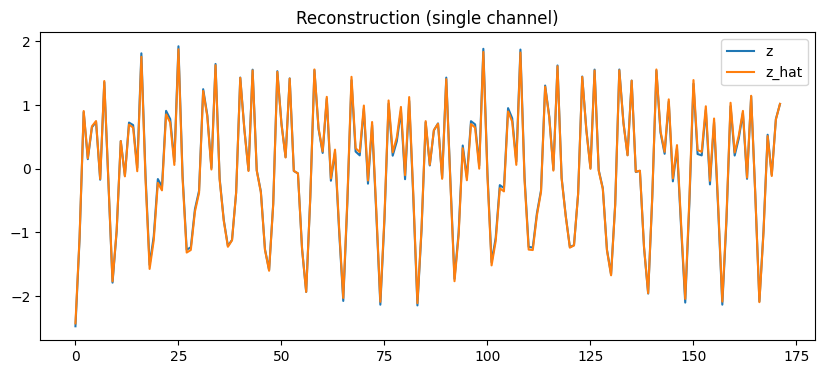

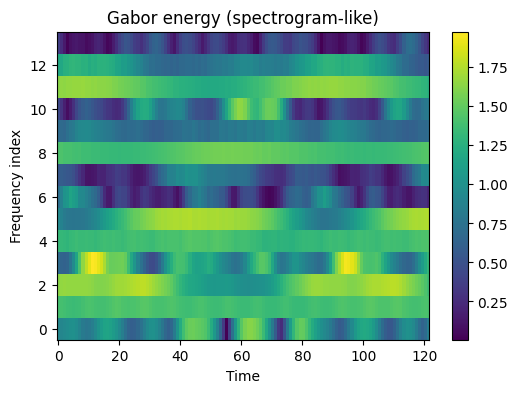

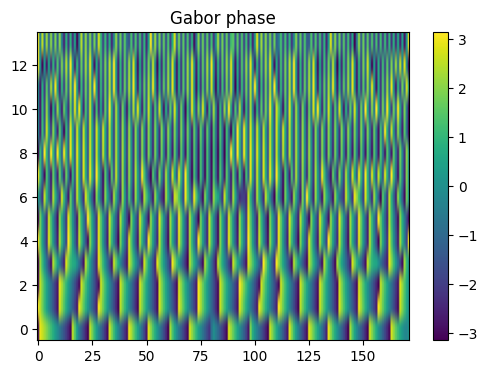

In [ ]:
# Single-channel regression (testing proof of concept)
b = 0
c = 0

z_c = z[b, c]
z_g_c = z_g[b, c]

n_features, T = z_g_c.shape

# Build regression matrix
X = z_g_c.T
y = z_c.unsqueeze(1)

# ridge stabilization
ridge = 1e-4
XtX = X.T @ X
Xty = X.T @ y

w = torch.linalg.solve(
    XtX + ridge * torch.eye(n_features, device=X.device),
    Xty)

# Reconstruction
y_hat = X @ w
z_hat_c = y_hat.squeeze(1)

# error
err = ((z_hat_c - z_c)**2).mean().item()
print("MSE:", err)

# Plot reconstruction
plt.figure(figsize=(10, 4))
plt.plot(z_c.detach().cpu(), label="z")
plt.plot(z_hat_c.detach().cpu(), label="z_hat")
plt.legend()
plt.title("Reconstruction (single channel)")
plt.show()

# Gabor visualization
F = n_features // 2
real = z_g_c[:F]
imag = z_g_c[F:]

pad = gabor.kernel_size // 2
energy = torch.sqrt(real**2 + imag**2)
energy_crop = energy[:, pad:-pad]

plt.figure(figsize=(6, 4))
plt.imshow(energy_crop.detach().cpu(), aspect='auto', origin='lower')
plt.title("Gabor energy (spectrogram-like)")
plt.xlabel("Time")
plt.ylabel("Frequency index")
plt.colorbar()
plt.show()

# phase
phase = torch.atan2(imag, real)

plt.figure(figsize=(6, 4))
plt.imshow(phase.detach().cpu(), aspect='auto', origin='lower')
plt.title("Gabor phase")
plt.colorbar()
plt.show()

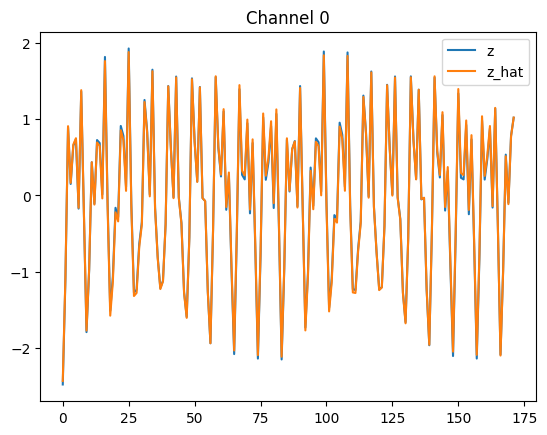

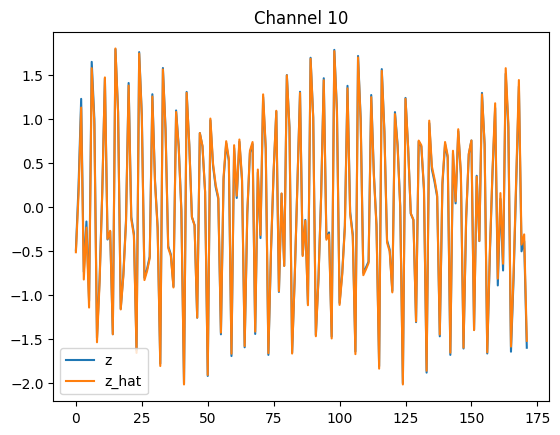

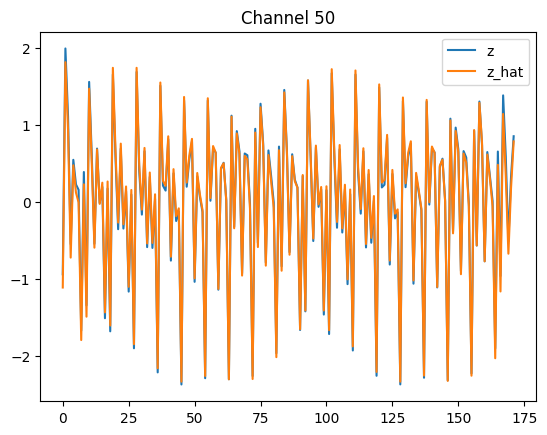

In [ ]:
# Expand to other single channels (does performance continue?)
for c in [0, 10, 50]:
    z_c = z[b, c]
    z_g_c = z_g[b, c]

    X = z_g_c.T
    y = z_c.unsqueeze(1)

    w = torch.linalg.lstsq(X, y).solution

    # Reconstruction
    z_hat = (X @ w).squeeze()

    plt.figure()
    plt.plot(z_c.cpu(), label="z")
    plt.plot(z_hat.detach().cpu(), label="z_hat")
    plt.title(f"Channel {c}")
    plt.legend()

  0%|          | 0/1024 [00:00<?, ?it/s]

Text(0, 0.5, 'Channel')

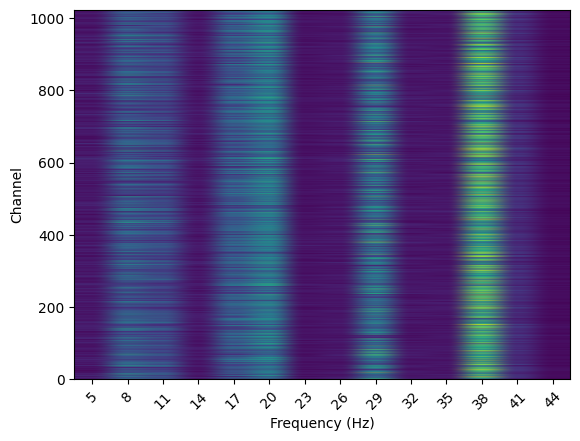

In [ ]:
# Expand to all channels and look at frequency distribution
C = 1024
all_weights = []

for c in tqdm(range(C)):
    z_c = z[b, c]
    z_g_c = z_g[b, c]

    X = z_g_c.T
    y = z_c.unsqueeze(1)

    w = torch.linalg.lstsq(X, y).solution
    all_weights.append(w.squeeze(-1))

W = torch.stack(all_weights)  # (C, 2F)

F = W.shape[1] // 2

W_real = W[:, :F]
W_imag = W[:, F:]

W_mag = torch.sqrt(W_real**2 + W_imag**2)

plt.imshow(W_mag.cpu(), aspect='auto', origin='lower')

plt.xticks(
    ticks=torch.arange(len(freqs_hz)),
    labels=[f"{int(f)}" for f in freqs_hz],
    rotation=45
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Channel")

Since the input chord had frequencies 220, 440, 660, and 880, we would expect the aliased frequencies (given sr = 86.13) to be ~38, 9, 29, and 19. The graph above has vertical stripes that align with each of these, and the width of each stripe is consistent with the ~3 Hz bandwidth set for the Gabor filters. So, the Gabor layer and subsequent conv are working as intended to isolate frequency proxies in the latent representation.

### Whole-Model Test

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class GaborBank(nn.Module):
    def __init__(self, freqs_norm, kernel_size=41):
        super().__init__()

        self.kernel_size = kernel_size
        self.freqs = freqs_norm
        self.n_freqs = len(freqs_norm)

        t = torch.arange(kernel_size) - kernel_size // 2

        window = torch.hann_window(kernel_size)
        window = window / (window.sum() + 1e-8)

        filters_real = []
        filters_imag = []

        for f in freqs_norm:
            g_real = window * torch.cos(2 * math.pi * f * t)
            g_imag = window * torch.sin(2 * math.pi * f * t)

            filters_real.append(g_real)
            filters_imag.append(g_imag)

        self.register_buffer("weight_real", torch.stack(filters_real)[:, None, :])
        self.register_buffer("weight_imag", torch.stack(filters_imag)[:, None, :])

    def forward(self, x):
        B, C, T = x.shape
        x = x.reshape(B * C, 1, T)

        pad = self.kernel_size // 2
        x = F.pad(x, (pad, pad), mode='reflect')

        y_r = F.conv1d(x, self.weight_real)
        y_i = F.conv1d(x, self.weight_imag)

        y = torch.cat([y_r, y_i], dim=1)

        y = y.reshape(B, C, 2 * self.n_freqs, T)
        return y

In [ ]:
duration = 2.0
sr = 44100
t_audio = int(duration * sr)
f0 = 220

x = gen_signal(f0, sr, 4, t_audio)

model3.eval()

with torch.no_grad():
    x = x.to(model3.device)
    z = model3.encoder(x)

    z = z - z.mean(dim=-1, keepdim=True)
    z = z / (z.std(dim=-1, keepdim=True) + 1e-6)

# baseline
with torch.no_grad():
    z_q = model3.quantizer(z)[0]
    x_hat = model3.decoder(z_q)

# Gabor
import torch.nn.functional as F # need to re-call because bad variable name

latent_sr = 86.13

freqs_hz = torch.arange(5, 45, 3)
freqs_norm = freqs_hz / latent_sr

gabor = GaborBank(freqs_norm, kernel_size=41).to(z.device)

z_g = gabor(z)

all_weights = []

b = 0

for c in range(z.shape[1]):
    z_c = z[b, c]
    z_g_c = z_g[b, c]

    X = z_g_c.T
    y = z_c.unsqueeze(1)

    ridge = 1e-4
    XtX = X.T @ X
    Xty = X.T @ y

    w = torch.linalg.solve(
        XtX + ridge * torch.eye(X.shape[1], device=X.device),
        Xty
    )

    all_weights.append(w.squeeze(1))

W = torch.stack(all_weights)

# reconstruct
z_hat = torch.einsum("bcft,cf->bct", z_g, W)

z_q_hat = model3.quantizer(z_hat)[0]
x_hat_g = model3.decoder(z_q_hat)

In [ ]:
# old latent to new latent MSE
((z_hat - z) ** 2).mean()

tensor(0.0017, device='cuda:0')

In [ ]:
# old signal to new signal MSE
mse = ((x_hat - x_hat_g) ** 2).mean()
mse

tensor(0.0003, device='cuda:0', grad_fn=<MeanBackward0>)

In [ ]:
# Log-mel diff
import torchaudio

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=44100,
    n_fft=1024,
    hop_length=256,
    n_mels=80
).to(x_hat.device)

logmel = lambda x: torch.log(mel(x) + 1e-6)

mel_diff = (logmel(x_hat) - logmel(x_hat_g)).abs().mean()
print("Log-mel diff:", mel_diff.item())

Log-mel diff: 0.365619957447052


The specs here are decent. Reconstruction fidelity doesn't meaningfully degrade, so this is a successful first ablation attempt. However, we do still log some fuzziness. This likely owes to the fuzziness of the Gabor layer.

3 Hz-wide Gabor filters is about as good as we can get. And this means we can only have a small number to comprehensively tile a space where Nyquist is ~43 Hz. This limit is set by the receptive field. It's better than the bandwidth given by the existing last layer (~8 Hz), but not selective enough to separate very closely spaced partials. Therefore, separability becomes harder as the signal becomes more dense and gaps between proxies get smaller. In this case, a Gabor channel may pick up 2+ components.

Furthermore, snake activations sometimes add additional components––unideal for this kind of representational goal.

Future work will aim to build a cleaner model with better selectivity. This requires choosing a suitable RF that balances expressivity and selectivity with the brevity of most audio events, an sr that doesn't induce collapse into alias orbits, and nonlinearities that introduce few additional harmonics (e.g., ELU, CELU).